## Data Set and Cleaning

### Importing Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
sales_path = "EREVData/master_sales_usa.csv"
vehicles_path = "EREVData/master_vehicles.csv"

In [3]:
df_sales = pd.read_csv(sales_path)
df_vehicles = pd.read_csv(vehicles_path)

In [4]:
#eliminate months after federal tax cut end
df_sales.drop(["2025-11", "2025-12"], axis = 1, inplace = True)
#elimnate some incomplete data
df_sales.drop(["2015-01", "2015-02", "2015-03", "2015-04", "2015-05", "2015-06", "2015-07", "2015-08", "2015-09", "2015-10", "2015-11", "2015-12"], axis = 1, inplace = True)

### Add Column - Luxury

In [5]:
#create luxury column for vehicles
luxury_map = {
    'Acura': 3, 'Audi': 3, 'BMW': 3, 'Cadillac': 3, 'Genesis': 3,
    'Infiniti': 3, 'Land Rover': 3, 'Lexus': 3, 'Lincoln': 3,
    'Lucid Motors': 3, 'Mercedes-Benz': 3, 'Porsche': 3,
    'Tesla': 3, 'Volvo Cars': 3,

    'Buick': 2, 'Chrysler': 2, 'GMC': 2, 'Jeep': 2,
    'Mazda': 2, 'MINI': 2, 'Ram': 2, 'VW': 2,

    'Chevrolet': 1, 'Dodge': 1, 'Ford': 1, 'Honda': 1,
    'Hyundai': 1, 'Kia': 1, 'Mitsubishi': 1,
    'Nissan': 1, 'Subaru': 1, 'Toyota': 1
}

df_luxury = pd.DataFrame(list(luxury_map.items()), columns=["Maker/Brand", "Luxury"])

In [6]:
df_vehicles = df_vehicles.merge(df_luxury, on = "Maker/Brand", how = "left")

In [7]:
#Confirm all vehicles are mapped to luxury score
df_vehicles[df_vehicles["Luxury"].isna()]

,Year,Maker/Brand,Model,PowerTrain,Accel_sec,TopSpeed_mph,mpg,mpge,energy_kwh_per_100mi,Range_mi,Power,Torque,Weight_lb,Payload_lb,Cargo_ft3,BodyStyle,Seats,Price_usd,Projected,Luxury


### Add Column - Initial Launch

In [8]:
# Structure: (Maker, Model, PowerTrain): (Year, Month)
launch_map = {
    
    # --- ACURA ---
    ("Acura", "ADX", "ICE"): (2025, 3),
    ("Acura", "MDX", "ICE"): (2000, 10),  # Initial Launch
    ("Acura", "RDX", "ICE"): (2006, 8),
    ("Acura", "TLX", "ICE"): (2014, 8),
    ("Acura", "ZDX", "EV"): (2024, 5),
    ("Acura", "Integra", "ICE"): (1986, 3),
    ("Acura", "ILX", "ICE"): (2012, 5),
    ("Acura", "MDX", "HV"): (2017, 4),
    ("Acura", "NSX", "HV"): (2016, 6),
    ("Acura", "RLX", "HV"): (2014, 9),
    ("Acura", "RLX", "ICE"): (2013, 3),
    ("Acura", "ILX", "HV"): (2012, 5),
    ("Acura", "TSX", "ICE"): (2003, 4),
    ("Acura", "TL", "ICE"): (1995, 3),
    ("Acura", "ZDX", "ICE"): (2009, 12),
    
        # --- AUDI ---
    ("Audi", "A6", "EV"): (2026, 4),          # A6 Sportback e-tron
    ("Audi", "Q6", "EV"): (2024, 12),         # Q6 e-tron
    ("Audi", "Q4 e-tron", "EV"): (2022, 3),
    ("Audi", "e-tron GT", "EV"): (2021, 7),
    ("Audi", "Q8 e-tron", "EV"): (2023, 6),
    ("Audi", "Q5", "PHV"): (2020, 10),
    ("Audi", "A7", "PHV"): (2020, 10),
    ("Audi", "A8", "PHV"): (2020, 10),
    ("Audi", "A3", "ICE"): (1996, 6),
    ("Audi", "A4", "ICE"): (1994, 11),
    ("Audi", "A5", "ICE"): (2007, 6),
    ("Audi", "A6", "ICE"): (1994, 6),
    ("Audi", "Q5", "ICE"): (2008, 8),
    ("Audi", "Q3", "ICE"): (2011, 6),
    ("Audi", "A7", "ICE"): (2010, 7),
    ("Audi", "A8", "ICE"): (1994, 6),
    ("Audi", "Q8", "ICE"): (2018, 12),
    ("Audi", "R8", "ICE"): (2006, 9),
    ("Audi", "e-tron", "EV"): (2019, 5),
    ("Audi", "TT", "ICE"): (1998, 9),
    ("Audi", "Q7", "ICE"): (2005, 9),
    ("Audi", "A3", "PHV"): (2014, 6),
    ("Audi", "A4 Allroad quattro", "ICE"): (2009, 2),
    ("Audi", "Q5", "HV"): (2011, 12),
    
        # --- BMW ---
    ("BMW", "i3", "EV"): (2013, 11),
    ("BMW", "i4", "EV"): (2021, 11),
    ("BMW", "i5", "EV"): (2023, 10),
    ("BMW", "i7", "EV"): (2022, 11),
    ("BMW", "iX", "EV"): (2021, 11),
    ("BMW", "3 Series", "PHV"): (2016, 3),
    ("BMW", "5 Series", "PHV"): (2017, 3),
    ("BMW", "7 Series", "PHV"): (2016, 8),
    ("BMW", "X5", "PHV"): (2015, 10),
    ("BMW", "XM", "PHV"): (2023, 3),
    ("BMW", "3 Series", "ICE"): (1975, 5),
    ("BMW", "X1", "ICE"): (2009, 10),
    ("BMW", "2 Series", "ICE"): (2014, 3),
    ("BMW", "X2", "ICE"): (2018, 3),
    ("BMW", "5 Series", "ICE"): (1972, 9),
    ("BMW", "4 Series", "ICE"): (2013, 10),
    ("BMW", "X3", "ICE"): (2003, 9),
    ("BMW", "6 Series", "ICE"): (1976, 3),
    ("BMW", "X4", "ICE"): (2014, 7),
    ("BMW", "Z4", "ICE"): (2002, 10),
    ("BMW", "7 Series", "ICE"): (1977, 5),
    ("BMW", "X5", "ICE"): (1999, 9),
    ("BMW", "X6", "ICE"): (2008, 4),
    ("BMW", "X7", "ICE"): (2019, 3),
    ("BMW", "8 Series", "ICE"): (1990, 5),
    ("BMW", "i8", "PHV"): (2014, 8),
    ("BMW", "X3", "PHV"): (2020, 3),
    ("BMW", "5 Series", "HV"): (2012, 3),
    ("BMW", "7 Series", "HV"): (2011, 3),
    ("BMW", "3 Series", "HV"): (2012, 9),
    
    
        # --- BUICK ---
    ("Buick", "Regal", "ICE"): (2010, 5),
    ("Buick", "Regal", "HV"): (2011, 10),

    # --- CADILLAC ---
    ("Cadillac", "Optiq", "EV"): (2025, 1),
    ("Cadillac", "Lyriq", "EV"): (2022, 9),
    ("Cadillac", "Vistiq", "EV"): (2025, 6),
    ("Cadillac", "Escalade", "EV"): (2024, 12),
    ("Cadillac", "XT4", "ICE"): (2018, 9),
    ("Cadillac", "CT4", "ICE"): (2020, 1),
    ("Cadillac", "CT5", "ICE"): (2019, 10),
    ("Cadillac", "XT5", "ICE"): (2016, 4),
    ("Cadillac", "XT6", "ICE"): (2019, 6),
    ("Cadillac", "Escalade", "ICE"): (1998, 8),
    ("Cadillac", "CT6", "ICE"): (2016, 3),
    ("Cadillac", "ATS", "ICE"): (2012, 8),
    ("Cadillac", "CTS", "ICE"): (2002, 1),
    ("Cadillac", "XTS", "ICE"): (2012, 6),
    ("Cadillac", "CT6", "PHV"): (2017, 4),
    ("Cadillac", "ELR", "PHV"): (2014, 1),
    ("Cadillac", "SRX", "ICE"): (2003, 9),
    ("Cadillac", "Escalade", "HV"): (2008, 8),
    
    # --- CHEVROLET ---
    ("Chevrolet", "Bolt", "EV"): (2016, 12),
    ("Chevrolet", "Bolt EUV", "EV"): (2021, 8),
    ("Chevrolet", "Equinox", "EV"): (2024, 5),
    ("Chevrolet", "Blazer", "EV"): (2023, 9),
    ("Chevrolet", "BrightDrop 400", "EV"): (2023, 8),
    ("Chevrolet", "BrightDrop 600", "EV"): (2021, 12),
    ("Chevrolet", "Silverado", "EV"): (2023, 9),
    ("Chevrolet", "Malibu", "ICE"): (1964, 1),
    ("Chevrolet", "Trax (Tracker)", "ICE"): (2013, 4),
    ("Chevrolet", "Trailblazer", "ICE"): (2001, 2),
    ("Chevrolet", "Equinox", "ICE"): (2004, 1),
    ("Chevrolet", "Blazer", "ICE"): (1969, 1),
    ("Chevrolet", "Traverse", "ICE"): (2008, 10),
    ("Chevrolet", "Camaro", "ICE"): (1966, 9),
    ("Chevrolet", "Colorado", "ICE"): (2003, 10),
    ("Chevrolet", "Corvette", "HV"): (2023, 10),
    ("Chevrolet", "Silverado", "ICE"): (1998, 8),
    ("Chevrolet", "Corvette", "ICE"): (1953, 6),
    ("Chevrolet", "C/K Suburban", "ICE"): (1935, 1),
    ("Chevrolet", "Tahoe", "ICE"): (1994, 2),
    ("Chevrolet", "Express", "ICE"): (1995, 6),
    ("Chevrolet", "Spark", "ICE"): (1998, 4),
    ("Chevrolet", "Sonic", "ICE"): (2011, 9),
    ("Chevrolet", "Impala", "ICE"): (1958, 1),
    ("Chevrolet", "Volt", "PHV"): (2010, 12),
    ("Chevrolet", "Malibu", "HV"): (2008, 1),
    ("Chevrolet", "Cruze", "ICE"): (2008, 10),
    ("Chevrolet", "City Express", "ICE"): (2014, 11),
    ("Chevrolet", "Caprice", "ICE"): (1965, 1),
    ("Chevrolet", "SS", "ICE"): (2013, 11),
    ("Chevrolet", "Spark", "EV"): (2013, 6),
    
        # --- CHRYSLER ---
    ("Chrysler", "Pacifica", "PHV"): (2017, 4),
    ("Chrysler", "Chrysler 300 Series", "ICE"): (2014, 12),
    ("Chrysler", "Pacifica", "ICE"): (2016, 4),
    ("Chrysler", "Chrysler 200 Series", "ICE"): (2014, 4),
    ("Chrysler", "Town & Country", "ICE"): (2007, 8),
    ("Chrysler", "Chrysler 300 series", "ICE"): (2014, 12),

    # --- DODGE ---
    ("Dodge", "Charger", "EV"): (2024, 12),
    ("Dodge", "Dodge Hornet", "PHV"): (2023, 8),
    ("Dodge", "Dart", "ICE"): (2012, 6),
    ("Dodge", "Dodge Hornet", "ICE"): (2023, 3),
    ("Dodge", "Journey", "ICE"): (2008, 3),
    ("Dodge", "Caravan", "ICE"): (2007, 8),
    ("Dodge", "Charger", "ICE"): (2014, 12),
    ("Dodge", "Durango", "ICE"): (2010, 12),
    ("Dodge", "Challenger", "ICE"): (2008, 5),
    ("Dodge", "Viper", "ICE"): (2012, 12),
    ("Dodge", "Avenger", "ICE"): (2007, 2),
    
        # --- FORD ---
    ("Ford", "Escape", "PHV"): (2020, 6),
    ("Ford", "Transit", "EV"): (2022, 2),
    ("Ford", "F-Series", "EV"): (2022, 5),
    ("Ford", "Escape", "HV"): (2004, 9),
    ("Ford", "Maverick", "HV"): (2022, 1),
    ("Ford", "Escape", "ICE"): (2000, 9),
    ("Ford", "Bronco Sport", "ICE"): (2020, 12),
    ("Ford", "Explorer", "HV"): (2019, 6),
    ("Ford", "Maverick", "ICE"): (1969, 4),
    ("Ford", "Explorer", "ICE"): (1990, 3),
    ("Ford", "Edge", "ICE"): (2006, 10),
    ("Ford", "Mustang", "ICE"): (1964, 4),
    ("Ford", "F-Series", "HV"): (2020, 12),
    ("Ford", "Ranger", "ICE"): (1982, 1),
    ("Ford", "F-Series", "ICE"): (1948, 1),
    ("Ford", "Bronco", "ICE"): (1965, 8),
    ("Ford", "Expedition", "ICE"): (1996, 10),
    ("Ford", "Transit", "ICE"): (1965, 10),
    ("Ford", "E-Series", "ICE"): (1960, 9),
    ("Ford", "Transit Connect", "ICE"): (2002, 1),
    ("Ford", "EcoSport", "ICE"): (2003, 1),
    ("Ford", "GT", "ICE"): (2004, 8),
    ("Ford", "Fusion", "PHV"): (2013, 2),
    ("Ford", "Fusion", "HV"): (2009, 3),
    ("Ford", "Fusion", "ICE"): (2005, 9),
    ("Ford", "Crown Victoria", "ICE"): (1991, 3),
    ("Ford", "Fiesta", "ICE"): (1976, 9),
    ("Ford", "Flex", "ICE"): (2008, 6),
    ("Ford", "C-MAX", "HV"): (2003, 9),
    ("Ford", "Focus", "ICE"): (1998, 7),
    ("Ford", "Taurus", "ICE"): (1985, 12),
    ("Ford", "Focus", "EV"): (2011, 12),
    ("Ford", "C-MAX", "PHV"): (2012, 10),
    ("Ford", "Mustang Mach-E", "EV"): (2020, 12),

    
    
        # --- GENESIS ---
    ("Genesis", "GV60", "EV"): (2022, 5),
    ("Genesis", "GV70", "EV"): (2023, 3),
    ("Genesis", "G80", "EV"): (2022, 8),

    ("Genesis", "G70", "ICE"): (2018, 9),
    ("Genesis", "GV70", "ICE"): (2021, 6),
    ("Genesis", "G80", "ICE"): (2016, 9),
    ("Genesis", "EQ900 (G90)", "ICE"): (2016, 10),
    ("Genesis", "GV80", "ICE"): (2020, 11),

    # --- GMC ---
    ("GMC", "Sierra", "EV"): (2024, 8),
    ("GMC", "Hummer SUV", "EV"): (2023, 3),
    ("GMC", "Hummer Pickup", "EV"): (2021, 12),
    ("GMC", "Terrain", "ICE"): (2009, 8),
    ("GMC", "Acadia", "ICE"): (2006, 12),
    ("GMC", "Canyon", "ICE"): (2003, 12),
    ("GMC", "Sierra", "ICE"): (1998, 8),
    ("GMC", "Yukon XL", "ICE"): (1999, 1),
    ("GMC", "Yukon", "ICE"): (1991, 1),
    ("GMC", "Savana", "ICE"): (1995, 9),
    ("GMC", "Sierra", "HV"): (2004, 1),
    ("GMC", "Yukon", "HV"): (2007, 12),
    
        # --- HONDA ---
    ("Honda", "Prologue", "EV"): (2024, 3),
    ("Honda", "CR-V", "FCV"): (2024, 7),
    ("Honda", "Civic", "HV"): (2001, 12),
    ("Honda", "Accord", "HV"): (2004, 12),
    ("Honda", "CR-V", "HV"): (2017, 7),
    ("Honda", "Civic", "ICE"): (1972, 7),
    ("Honda", "Accord", "ICE"): (1976, 5),
    ("Honda", "CR-V", "ICE"): (1995, 10),
    ("Honda", "HR-V", "ICE"): (1998, 9),
    ("Honda", "Passport", "ICE"): (1993, 11),
    ("Honda", "Odyssey", "ICE"): (1994, 10),
    ("Honda", "Pilot", "ICE"): (2002, 6),
    ("Honda", "Ridgeline", "ICE"): (2005, 3),
    ("Honda", "Insight", "HV"): (1999, 11),
    ("Honda", "Clarity Plug In", "PHV"): (2017, 12),
    ("Honda", "Clarity Fuel Cell", "FCV"): (2016, 12),
    ("Honda", "Clarity Electric", "EV"): (2017, 8),
    ("Honda", "Fit (Jazz)", "ICE"): (2001, 6),
    ("Honda", "CR-Z", "HV"): (2010, 2),
    ("Honda", "Crosstour", "ICE"): (2009, 11),
    ("Honda", "Fit (Jazz)", "EV"): (2012, 7),
    ("Honda", "Accord", "PHV"): (2013, 1),
    ("Honda", "FCX Clarity", "FCV"): (2008, 7),
    
        # --- HYUNDAI ---
    ("Hyundai", "IONIQ 6", "EV"): (2022, 11),
    ("Hyundai", "Kona", "EV"): (2018, 5),
    ("Hyundai", "IONIQ 5", "EV"): (2021, 5),
    ("Hyundai", "Ioniq 9", "EV"): (2025, 5),
    ("Hyundai", "Tucson", "PHV"): (2021, 9),
    ("Hyundai", "Santa Fe", "PHV"): (2021, 9),
    ("Hyundai", "Nexo", "FCV"): (2018, 3),
    ("Hyundai", "Avante (Elantra)", "HV"): (2009, 7),
    ("Hyundai", "Sonata", "HV"): (2011, 1),
    ("Hyundai", "Tucson", "HV"): (2020, 10),
    ("Hyundai", "Santa Fe", "HV"): (2020, 10),
    ("Hyundai", "Avante (Elantra)", "ICE"): (1990, 10),
    ("Hyundai", "Sonata", "ICE"): (1985, 11),
    ("Hyundai", "Venue", "ICE"): (2019, 5),
    ("Hyundai", "Kona", "ICE"): (2017, 6),
    ("Hyundai", "Tucson", "ICE"): (2004, 8),
    ("Hyundai", "Santa Fe", "ICE"): (2000, 11),
    ("Hyundai", "Santa Cruz", "ICE"): (2021, 7),
    ("Hyundai", "Palisade", "ICE"): (2018, 11),
    ("Hyundai", "Accent (Verna)", "ICE"): (1994, 10),
    ("Hyundai", "Veloster", "ICE"): (2011, 3),
    ("Hyundai", "Ioniq", "EV"): (2016, 7),
    ("Hyundai", "Ioniq", "PHV"): (2017, 2),
    ("Hyundai", "Ioniq", "HV"): (2016, 1),
    ("Hyundai", "Sonata", "PHV"): (2015, 11),
    ("Hyundai", "Azera", "ICE"): (1986, 7),
    ("Hyundai", "Genesis", "ICE"): (2008, 1),
    ("Hyundai", "Equus", "ICE"): (1999, 4),

    # Not a real launchable nameplate; leave unmapped or handle separately.
    # ("Hyundai", "Other/Adjustment", "ICE"): (None, None),

    
        # --- INFINITI ---
    ("Infiniti", "QX50", "ICE"): (2013, 7),
    ("Infiniti", "QX55", "ICE"): (2021, 4),
    ("Infiniti", "QX60", "ICE"): (2013, 7),
    ("Infiniti", "Q50", "ICE"): (2013, 8),
    ("Infiniti", "QX80", "ICE"): (2013, 7),
    ("Infiniti", "Q60", "ICE"): (2013, 7),
    ("Infiniti", "QX30", "ICE"): (2016, 9),
    ("Infiniti", "Q50", "HV"): (2013, 8),
    ("Infiniti", "Q70", "HV"): (2013, 7),
    ("Infiniti", "Q70", "ICE"): (2013, 7),
    ("Infiniti", "QX70", "ICE"): (2013, 7),
    ("Infiniti", "QX60", "HV"): (2013, 10),
    
    
        # --- JEEP ---
    ("Jeep", "Wagoneer S", "EV"): (2025, 1),

    ("Jeep", "Grand Cherokee", "PHV"): (2022, 2),
    ("Jeep", "Wrangler", "PHV"): (2021, 1),

    ("Jeep", "Compass", "ICE"): (2017, 3),
    ("Jeep", "Renegade", "ICE"): (2015, 3),
    ("Jeep", "Cherokee", "ICE"): (2013, 10),
    ("Jeep", "Patriot", "ICE"): (2006, 9),
    ("Jeep", "Grand Cherokee", "ICE"): (1992, 12),
    ("Jeep", "Wrangler", "ICE"): (1986, 11),
    ("Jeep", "Gladiator", "ICE"): (2019, 4),
    ("Jeep", "Wagoneer", "ICE"): (2021, 9),
    ("Jeep", "Grand Wagoneer", "ICE"): (2021, 9),
    
        # --- KIA ---
    ("Kia", "EV6", "EV"): (2021, 8),
    ("Kia", "Soul", "EV"): (2014, 10),
    ("Kia", "Niro", "EV"): (2018, 5),
    ("Kia", "Niro", "PHV"): (2017, 12),
    ("Kia", "EV9", "EV"): (2023, 11),
    ("Kia", "Sportage", "PHV"): (2022, 7),
    ("Kia", "Sorento (KX7)", "PHV"): (2021, 8),
    ("Kia", "Niro", "HV"): (2016, 1),
    ("Kia", "Sportage", "HV"): (2022, 3),
    ("Kia", "Sorento (KX7)", "HV"): (2020, 10),
    ("Kia", "Carnival", "HV"): (2024, 6),
    ("Kia", "K5", "ICE"): (2010, 1),
    ("Kia", "Soul", "ICE"): (2008, 9),
    ("Kia", "K4", "ICE"): (2014, 8),
    ("Kia", "Seltos", "ICE"): (2019, 7),
    ("Kia", "Sportage", "ICE"): (1993, 7),
    ("Kia", "Sorento (KX7)", "ICE"): (2017, 3),
    ("Kia", "Telluride", "ICE"): (2019, 2),
    ("Kia", "Carnival", "ICE"): (1998, 1),
    ("Kia", "Rio", "ICE"): (1999, 11),
    ("Kia", "Forte", "ICE"): (2008, 10),
    ("Kia", "Stinger", "ICE"): (2017, 5),
    ("Kia", "Optima", "ICE"): (2000, 10),
    ("Kia", "Cadenza", "ICE"): (2009, 11),
    ("Kia", "Optima", "PHV"): (2016, 12),
    ("Kia", "Optima", "HV"): (2011, 2),
    
        # --- LAND ROVER ---
    ("Land Rover", "Range Rover", "PHV"): (2018, 7),
    ("Land Rover", "Range Rover Sport", "PHV"): (2018, 7),

    ("Land Rover", "Discovery Sport", "ICE"): (2015, 5),
    ("Land Rover", "Range Rover Evoque", "ICE"): (2011, 10),
    ("Land Rover", "Range Rover Velar", "ICE"): (2017, 8),
    ("Land Rover", "Defender", "ICE"): (1983, 6),
    ("Land Rover", "Range Rover Sport", "ICE"): (2005, 8),
    ("Land Rover", "Range Rover", "ICE"): (1970, 12),
    ("Land Rover", "LR4", "ICE"): (2009, 9),
    ("Land Rover", "LR2", "ICE"): (2007, 6),
    
    
    
        # --- LEXUS ---
    ("Lexus", "RZ", "EV"): (2023, 3),   # RZ 450e went on sale in early 2023
    ("Lexus", "NX", "PHV"): (2021, 11), # NX 450h+ plug-in hybrid launched in late 2021
    ("Lexus", "RX", "PHV"): (2022, 11), # RX 450h+ launched globally with the 5th-gen redesign
    ("Lexus", "TX", "PHV"): (2024, 1),  # TX 550h+ followed in early 2024

    ("Lexus", "ES", "HV"): (2012, 8),   # ES 300h debuted with the 6th generation in August 2012
    ("Lexus", "UX", "HV"): (2018, 12),  # UX 250h went on sale in late 2018
    ("Lexus", "NX", "HV"): (2014, 7),   # NX 300h hybrid originally went on sale in July 2014
    ("Lexus", "RX", "HV"): (2005, 4),   # RX 400h (first premium hybrid crossover) launched in April 2005
    ("Lexus", "GS", "HV"): (2006, 3),   # GS 450h hybrid launched in March 2006
    ("Lexus", "TX", "HV"): (2023, 10),  # TX 500h hybrid launched in October 2023
    ("Lexus", "LC", "HV"): (2017, 5),   # LC 500h hybrid launched in May 2017

    ("Lexus", "NX", "ICE"): (2014, 7),  # NX 200t went on sale in July 2014
    ("Lexus", "ES", "ICE"): (1989, 9),  # ES 250 debuted at the initial Lexus brand launch in September 1989
    ("Lexus", "LS", "HV"): (2007, 7),   # LS 600h hybrid launched in July 2007
    ("Lexus", "RX", "ICE"): (1998, 3),  # Original RX 300 export sales started in March 1998
    ("Lexus", "TX", "ICE"): (2023, 10), # TX 350 went on sale in October 2023
    ("Lexus", "GS", "ICE"): (1993, 2),  # Original GS 300 export sales started in February 1993
    ("Lexus", "IS", "ICE"): (1999, 5),  # IS 200 launched in Europe in May 1999
    ("Lexus", "RC", "ICE"): (2014, 10), # RC 350 and RC F went on sale in October 2014

    ("Lexus", "LX", "HV"): (2025, 12),  # LX 700h twin-turbo hybrid rolled out in late 2025
    ("Lexus", "LX", "ICE"): (1996, 1),  # Original LX 450 launched in January 1996
    ("Lexus", "LS", "ICE"): (1989, 9),  # Flagship LS 400 debuted at brand launch in September 1989
    ("Lexus", "LC", "ICE"): (2017, 5),  # LC 500 went on sale in May 2017
    ("Lexus", "GX", "ICE"): (2002, 11), # Original GX 470 went on sale in November 2002
    ("Lexus", "UX", "ICE"): (2018, 12), # UX 200 launched in December 2018
    ("Lexus", "LFA", "ICE"): (2010, 12),# Production of the limited supercar began in December 2010
    ("Lexus", "CT", "HV"): (2011, 3),   # CT 200h went on sale in March 2011
    
        # --- LINCOLN ---
    ("Lincoln", "Corsair", "PHV"): (2020, 11),       # Corsair Grand Touring plug-in hybrid hit U.S. dealerships in late 2020
    ("Lincoln", "Nautilus", "HV"): (2024, 1),        # The second-generation Nautilus introduced the hybrid powertrain in early 2024

    ("Lincoln", "Corsair", "ICE"): (2019, 9),        # Replaced the MKC and went on sale in September 2019
    ("Lincoln", "Nautilus", "ICE"): (2018, 11),      # The Nautilus nameplate launched as a mid-cycle refresh of the MKX in late 2018
    ("Lincoln", "Aviator", "ICE"): (2002, 11),       # The original body-on-frame Aviator V8 launched in late 2002 for the 2003 model year
    ("Lincoln", "Navigator", "ICE"): (1997, 5),      # The definitive full-size luxury SUV originally went on sale in May 1997
    ("Lincoln", "Aviator", "PHV"): (2019, 8),        # Aviator Grand Touring plug-in hybrid launched with the second generation in August 2019

    ("Lincoln", "MKZ", "HV"): (2010, 9),             # The MKZ Hybrid debuted for the 2011 model year in September 2010
    ("Lincoln", "MKZ", "ICE"): (2005, 10),           # Originally launched as the Lincoln Zephyr in October 2005 before being renamed MKZ for 2007
    ("Lincoln", "Continental", "ICE"): (1939, 10),   # The legendary flagship first entered production in October 1939 for the 1940 model year
    ("Lincoln", "MKT", "ICE"): (2009, 7),            # The large three-row crossover went on sale in July 2009
    ("Lincoln", "MKC", "ICE"): (2014, 5),            # Lincoln's first compact premium crossover began customer deliveries in May 2014
    ("Lincoln", "MKX", "ICE"): (2006, 12),           # The original first-generation midsize crossover went on sale in December 2006
    ("Lincoln", "MKS", "ICE"): (2008, 6),            # Lincoln's full-size luxury sedan hit showrooms in June 2008

    # --- LUCID MOTORS ---
    ("Lucid Motors", "Air", "EV"): (2021, 10),
    ("Lucid Motors", "Gravity", "EV"): (2025, 1),
    
    
        # --- MAZDA ---
    ("Mazda", "CX-90", "PHV"): (2023, 4),             # Went on sale in North America in April 2023
    ("Mazda", "CX-70", "PHV"): (2024, 4),             # Hit dealerships in Spring (April) 2024
    ("Mazda", "CX-50", "HV"): (2023, 11),             # Officially went on sale first in China in November 2023 (US followed in 2024)

    ("Mazda", "Axela (Mazda 3)", "ICE"): (2003, 10),  # The original BK-generation Axela/Mazda3 launched in October 2003
    ("Mazda", "CX-30", "ICE"): (2019, 10),            # Went on sale first in Japan on October 24, 2019
    ("Mazda", "MX-5 (Miata)", "ICE"): (1989, 5),      # The iconic NA Miata went on sale in May 1989
    ("Mazda", "CX-5", "ICE"): (2012, 2),              # First-generation crossover went on sale in February 2012
    ("Mazda", "CX-50", "ICE"): (2022, 4),             # The rugged crossover went on sale in North America in April 2022

    ("Mazda", "CX-70", "MHV"): (2024, 4),             # Launched alongside the PHEV variant in April 2024
    ("Mazda", "CX-90", "MHV"): (2023, 4),             # The e-Skyactiv G mild-hybrid inline-six launched in April 2023

    ("Mazda", "CX-9", "ICE"): (2007, 1),              # First-generation three-row SUV officially went on sale in January 2007
    ("Mazda", "MX-30", "EV"): (2020, 9),              # Mazda's first production EV arrived in European showrooms in September 2020
    ("Mazda", "CX-90", "ICE"): (2023, 4),             # Because all standard inline-6 CX-90s are mild hybrids, this matches the MHV launch
    ("Mazda", "Atenza (Mazda 6)", "ICE"): (2002, 5),  # The first-generation Atenza/Mazda6 went on sale in May 2002
    ("Mazda", "CX-3", "ICE"): (2015, 2),              # Launched nationwide in Japan in February 2015
    ("Mazda", "Premacy (Mazda 5)", "ICE"): (1999, 4), # The first-generation Premacy mini-MPV debuted in April 1999
    ("Mazda", "Demio (Mazda 2)", "ICE"): (1996, 8),   # The original first-generation Demio launched in August 1996

        # --- MERCEDES-BENZ ---
    ("Mercedes-Benz", "EQB", "EV"): (2021, 11),                       # Production and sales began in Europe/China in late 2021
    ("Mercedes-Benz", "EQE", "EV"): (2022, 5),                        # The EQE sedan officially launched for customer orders in May 2022
    ("Mercedes-Benz", "EQS", "EV"): (2021, 8),                        # High-end flagship liftback sales launched in Europe in August 2021
    ("Mercedes-Benz", "Sprinter", "EV"): (2019, 12),                 # The original global eSprinter first launched in Europe in late 2019
    ("Mercedes-Benz", "EQE SUV", "EV"): (2022, 12),                  # Production and global sales launched in December 2022
    ("Mercedes-Benz", "EQS SUV", "EV"): (2022, 8),                   # Production and initial customer deliveries began in August 2022
    ("Mercedes-Benz", "G-Class", "EV"): (2024, 12),                  # The electric G 580 with EQ Technology opened for global orders in late 2024

    ("Mercedes-Benz", "C-Class", "PHV"): (2015, 3),                  # The C 350 e (W205 generation) plug-in hybrid went on sale in March 2015
    ("Mercedes-Benz", "GLC-Class (GLK-Class)", "PHV"): (2016, 6),    # The GLC 350e plug-in hybrid arrived at showrooms in mid-2016
    ("Mercedes-Benz", "S-Class", "PHV"): (2014, 9),                  # The S 500 e Plug-in Hybrid (W222) initially went on sale in September 2014
    ("Mercedes-Benz", "GLE-Class (M-Class/ML-Class)", "PHV"): (2015, 8), # The GLE 500e plug-in hybrid was launched globally in August 2015
    ("Mercedes-Benz", "AMG-GT", "PHV"): (2022, 2),                   # The ultra-performance GT 63 S E Performance 4-door opened for orders in February 2022
    ("Mercedes-Benz", "SL-Class", "PHV"): (2024, 4),                  # The AMG SL 63 S E Performance plug-in hybrid launched in early 2024

    ("Mercedes-Benz", "CLA-Class", "ICE"): (2013, 4),                # The original C117 CLA-Class four-door coupe went on sale in April 2013
    ("Mercedes-Benz", "GLA-Class", "ICE"): (2014, 3),                # The first-generation X156 premium subcompact went on sale in March 2014
    ("Mercedes-Benz", "C-Class", "ICE"): (1993, 5),                  # The official "C-Class" nameplate launched with the W202 in May 1993
    ("Mercedes-Benz", "GLB", "ICE"): (2019, 11),                     # The compact boxy X247 crossover launched in late November 2019
    ("Mercedes-Benz", "CLE Coupe", "ICE"): (2023, 11),               # Initial European customer deliveries of the CLE Coupe began in November 2023
    ("Mercedes-Benz", "E-Class", "ICE"): (1993, 5),                  # The official "E-Class" nameplate launched with the facelifted W124 in May 1993
    ("Mercedes-Benz", "GLC-Class (GLK-Class)", "ICE"): (2008, 10),   # Its direct predecessor, the GLK-Class, originally hit showrooms in October 2008
    ("Mercedes-Benz", "CLS-Class", "ICE"): (2004, 10),               # The original W219 "four-door coupe" launched globally in October 2004
    ("Mercedes-Benz", "GLE-Class (M-Class/ML-Class)", "ICE"): (1997, 9), # The foundational luxury midsize SUV (M-Class) went on sale in September 1997
    ("Mercedes-Benz", "S-Class", "ICE"): (1972, 9),                  # The official "S-Class" naming convention began with the W116 in September 1972
    ("Mercedes-Benz", "AMG-GT", "ICE"): (2015, 3),                   # Deliveries for the original 2-door coupe variant started in March 2015
    ("Mercedes-Benz", "SL-Class", "ICE"): (1954, 3),                  # Traces straight back to the production launch of the iconic 300 SL Gullwing in March 1954
    ("Mercedes-Benz", "GLS-Class (GL-Class)", "ICE"): (2006, 6),     # The full-size three-row SUV (originally the GL-Class) went on sale in June 2006
    ("Mercedes-Benz", "G-Class", "MHV"): (2024, 6),                  # Mild-hybrid powertrains integrated into the legendary SUV starting with the June 2024 update
    ("Mercedes-Benz", "A-Class", "ICE"): (1997, 10),                 # The original front-wheel-drive W168 subcompact hatchback launched in October 1997
    ("Mercedes-Benz", "G-Class", "ICE"): (1979, 2),                  # The original civilian-market Geländewagen (W460) debuted in February 1979
    
        # --- MINI ---
    ("MINI", "Cooper", "EV"): (2020, 3),         # First mass-production Cooper SE hardtop customer deliveries began in March 2020
    ("MINI", "Countryman", "EV"): (2024, 3),     # The all-electric U25-generation Countryman E/SE entered production and hit European showrooms in March 2024
    ("MINI", "Countryman", "PHV"): (2017, 6),    # The Cooper S E Countryman ALL4 plug-in hybrid officially went on sale in June 2017

    ("MINI", "Cooper", "ICE"): (1961, 9),        # The legendary performance-tuned Austin/Morris Mini Cooper debuted in September 1961 (BMW's modern reboot went on sale in July 2001)
    ("MINI", "Convertible", "ICE"): (2004, 4),   # The first modern premium open-top MINI convertible launched in April 2004
    ("MINI", "Countryman", "ICE"): (2010, 9),    # The first-generation R60 subcompact crossover went on sale in European markets in September 2010
    ("MINI", "Clubman", "ICE"): (1969, 10),      # The original British Leyland Mini Clubman with its characteristic squared nose debuted in October 1969 (Modern version launched in November 2007)
    ("MINI", "Paceman", "ICE"): (2013, 3),       # The distinctive three-door crossover coupe officially hit dealerships in March 2013
    ("MINI", "Coupe", "ICE"): (2011, 10),        # The unique two-seat hardtop coupe version officially went on sale on October 1, 2011
    ("MINI", "Roadster", "ICE"): (2012, 2),      # The open-top twin to the Coupe arrived at global dealerships on February 25, 2012
    
        # --- MITSUBISHI ---
    ("Mitsubishi", "Outlander", "PHV"): (2013, 1),                 # The world's first plug-in hybrid SUV went on sale in Japan in January 2013
    ("Mitsubishi", "Mirage", "ICE"): (1978, 3),                     # The original first-generation subcompact Mirage launched in March 1978
    ("Mitsubishi", "RVR/ASX/Outlander Sport", "ICE"): (1991, 2),    # The original first-generation RVR space-runner debuted in February 1991
    ("Mitsubishi", "Outlander", "ICE"): (2001, 6),                  # Originally launched in Japan as the Airtrek in June 2001 before export renaming
    ("Mitsubishi", "Eclipse Cross", "ICE"): (2017, 10),             # Global production and initial rollouts began in October 2017
    ("Mitsubishi", "Lancer", "ICE"): (1973, 2),                     # The historic compact sedan line originally launched in February 1973
    ("Mitsubishi", "i-MiEV", "EV"): (2009, 7),                      # Mass production and initial fleet customer sales began in Japan in July 2009
    
    
        # --- NISSAN ---
# --- NISSAN ---
    ("Nissan", "Leaf", "EV"): (2010, 10),              # Production officially began in October 2010 at the Oppama plant
    ("Nissan", "Ariya", "EV"): (2022, 1),              # Production of the all-electric crossover began in January 2022

    ("Nissan", "Versa", "ICE"): (2006, 7),             # Hit the North American market as a standalone nameplate in July 2006
    ("Nissan", "Kicks", "ICE"): (2016, 8),             # Launched globally first in Brazil in August 2016 to support the Rio Olympics
    ("Nissan", "Sentra", "ICE"): (1982, 5),            # The first-generation Sentra replaced the Datsun 210 in May 1982
    ("Nissan", "Altima", "ICE"): (1992, 6),            # Replaced the Stanza and went into production/sales in June 1992
    ("Nissan", "Rogue", "ICE"): (2007, 10),            # The first-generation crossover officially hit showrooms in October 2007
    ("Nissan", "Maxima", "ICE"): (1981, 1),            # The Maxima nameplate debuted for the 1981 model year (transitioning from the Datsun 810)
    ("Nissan", "Pathfinder", "ICE"): (1985, 4),        # Production of the first-gen body-on-frame platform began in April 1985
    ("Nissan", "Murano", "ICE"): (2002, 6),            # Shipments to initial U.S. dealerships began in early June 2002
    ("Nissan", "Z", "ICE"): (2022, 4),                 # The RZ34-generation "Nissan Z" officially entered production in April 2022
    ("Nissan", "Frontier (Navara)", "ICE"): (1997, 9), # The D22-generation pickup truck launched globally in September 1997
    ("Nissan", "Titan", "ICE"): (2003, 12),            # Nissan's full-size truck went on sale nationwide on December 1, 2003
    ("Nissan", "GT-R", "ICE"): (2007, 12),             # The legendary production R35 GT-R went on sale in Japan in December 2007
    ("Nissan", "Armada", "ICE"): (2003, 10),           # Originally went on sale as the "Pathfinder Armada" in October 2003

    ("Nissan", "Rogue", "HV"): (2016, 11),             # The first-generation Rogue Hybrid rolled into showrooms in November 2016

    ("Nissan", "NV200", "ICE"): (2009, 5),             # Went on sale in Japan as the NV200 Vanette in May 2009
    ("Nissan", "NV", "ICE"): (2011, 3),                # The full-size commercial van lineup for North America launched in March 2011
    ("Nissan", "370Z", "ICE"): (2008, 12),             # The 370Z coupe officially hit the market in December 2008
    ("Nissan", "Juke", "ICE"): (2010, 6),              # On-sale dates globally kicked off first in Japan in June 2010
    ("Nissan", "Quest", "ICE"): (1992, 4),             # Production of the joint-venture minivan began in April 1992
    ("Nissan", "Pathfinder", "HV"): (2013, 10),        # The R52-generation hybrid variant launched in October 2013
    ("Nissan", "Xterra", "ICE"): (1999, 5),            # The rugged, truck-based compact SUV originally went on sale in May 1999
    ("Nissan", "Cube", "ICE"): (1998, 2),              # The first-generation Z10 Cube debuted in Japan in February 1998
    
        # --- PORSCHE ---
    ("Porsche", "Macan", "EV"): (2024, 5),          # Second-generation all-electric Macan series production began in May 2024
    ("Porsche", "Taycan", "EV"): (2019, 9),         # Mass production of the first customer Taycans began in September 2019

    ("Porsche", "Panamera", "PHV"): (2013, 11),     # The Panamera S E-Hybrid plug-in hybrid officially launched in November 2013
    ("Porsche", "Cayenne", "PHV"): (2014, 10),      # The Cayenne S E-Hybrid plug-in hybrid debuted at the Paris Motor Show in October 2014

    ("Porsche", "Macan", "ICE"): (2014, 2),         # Production of the original internal combustion Macan began in February 2014
    ("Porsche", "Panamera", "ICE"): (2009, 9),      # The original gas-powered Panamera model line hit the market in September 2009
    ("Porsche", "Boxster/Cayman", "ICE"): (1996, 8),# The foundational 986 Boxster went into series production in August 1996 (Cayman coupe followed in 2005)
    ("Porsche", "Cayenne", "ICE"): (2002, 12),      # The first-generation luxury utility vehicle hit the market in December 2002
    ("Porsche", "911", "ICE"): (1964, 9),           # The legendary flagship 911 officially entered series production in September 1964
    ("Porsche", "918", "ICE"): (2013, 9),           # Series production of the mid-engined hybrid supercar began on September 18, 2013
    
    # --- RAM ---
    ("Ram", "ProMaster", "EV"): (2024, 1),          # The all-electric ProMaster EV began initial fleet deliveries in January 2024
    ("Ram", "ProMaster City", "ICE"): (2015, 1),     # The compact commercial van officially went on sale in January 2015
    ("Ram", "Ram P/U", "ICE"): (1980, 10),           # The iconic "Ram" pickup nameplate originally debuted in October 1980 (later spun off as a standalone brand in October 2009)
    ("Ram", "ProMaster", "ICE"): (2013, 10),         # The full-size internal combustion ProMaster officially hit the market in October 2013
    ("Ram", "Ram Cargo Van", "ICE"): (2011, 9),      # The minivan-based Ram C/V Tradesman went on sale for commercial fleets in September 2011
    
        # --- SUBARU ---
    ("Subaru", "Solterra", "EV"): (2022, 5),          # Global retail launch and customer deliveries began in May 2022
    ("Subaru", "XV", "PHV"): (2018, 12),              # The plug-in hybrid version (Crosstrek Hybrid in the U.S.) went on sale in December 2018
    ("Subaru", "Forester", "HV"): (2018, 9),          # Initial global launch of the Forester "e-Boxer" hybrid in Japan occurred in September 2018

    ("Subaru", "Impreza", "ICE"): (1992, 11),         # The first-generation Impreza officially launched in Japan in November 1992
    ("Subaru", "Forester", "ICE"): (1997, 2),          # The original internal-combustion Forester debuted in Japan in February 1997
    ("Subaru", "Crosstrek", "ICE"): (2012, 4),        # The compact crossover line made its official retail market debut in April 2012
    ("Subaru", "Legacy", "ICE"): (1989, 2),           # The long-running sedan/wagon family launched in Japan in February 1989
    ("Subaru", "Outback", "ICE"): (1994, 8),          # Originally introduced as the high-riding Legacy Grand Wagon in August 1994
    ("Subaru", "BRZ", "ICE"): (2012, 3),              # The production co-developed sports car went on sale in Japan in March 2012
    ("Subaru", "Ascent", "ICE"): (2018, 6),           # Deliveries of the flagship three-row SUV began in June 2018
    ("Subaru", "WRX", "ICE"): (2014, 3),              # Launched as a distinct standalone nameplate independent of the Impreza line in March 2014
    ("Subaru", "XV", "ICE"): (2011, 12),              # The global standalone version went on sale in late December 2011 before hitting North America in 2012
    ("Subaru", "XV", "HV"): (2013, 6),                # The first-generation non-plug-in XV Hybrid went on sale first in Japan in June 2013
    
        # --- TESLA ---
    ("Tesla", "Model 3", "EV"): (2017, 7),
    ("Tesla", "Model Y", "EV"): (2020, 3),
    ("Tesla", "Model S", "EV"): (2012, 6),
    ("Tesla", "Model X", "EV"): (2015, 9),
    ("Tesla", "Cybertruck", "EV"): (2023, 11),
    
    # --- TOYOTA ---
    ("Toyota", "Prius", "PHV"): (2012, 1),            # The first-generation mass-production Prius PHEV launched in Japan in January 2012
    ("Toyota", "bZ4X/bZ", "EV"): (2022, 5),           # Co-developed EV crossover deliveries began globally in May 2022
    ("Toyota", "RAV4", "PHV"): (2020, 6),             # RAV4 PHV (Prime) officially went on sale in Japan on June 8, 2020
    ("Toyota", "MIRAI", "FCV"): (2014, 12),           # The world's first mass-produced hydrogen fuel cell car launched in December 2014

    ("Toyota", "Prius", "HV"): (1997, 12),            # The foundational world-first mass-market hybrid went on sale in December 1997
    ("Toyota", "Corolla", "HV"): (2013, 8),           # The Corolla Axio and Fielder hybrids originally launched in Japan in August 2013
    ("Toyota", "Camry", "HV"): (2006, 5),             # The original Camry Hybrid went on sale in May 2006 for the 2007 model year
    ("Toyota", "Corolla Cross", "HV"): (2020, 7),     # Launched globally first in Thailand in July 2020 alongside the gas version
    ("Toyota", "Crown", "HV"): (2001, 8),             # The Crown Royal Saloon Mild Hybrid launched back in August 2001 (Full Hybrid variant followed in May 2008)
    ("Toyota", "RAV4", "HV"): (2015, 11),             # The RAV4 Hybrid officially hit the market in November 2015
    ("Toyota", "Venza", "HV"): (2020, 9),             # The second-generation Venza returned as an all-hybrid line in September 2020
    ("Toyota", "Crown Signia", "HV"): (2024, 6),      # The premium crossover wagon went on sale in June 2024
    ("Toyota", "Sienna", "HV"): (2020, 11),           # The fourth-generation Sienna moved exclusively to a hybrid powertrain in November 2020
    ("Toyota", "Grand Highlander", "HV"): (2023, 7),  # The extended three-row crossover hybrid variant launched in July 2023
    ("Toyota", "Highlander", "HV"): (2005, 7),        # The original Highlander Hybrid (Kluger Hybrid in Japan) debuted in July 2005

    ("Toyota", "Corolla", "ICE"): (1966, 11),         # The history-making first-generation Corolla hit the market in November 1966
    ("Toyota", "Camry", "ICE"): (1982, 3),            # Spun off from the Celica Camry line and launched standalone in March 1982
    ("Toyota", "Corolla Cross", "ICE"): (2020, 7),    # Debuted alongside the hybrid in Thailand in July 2020
    ("Toyota", "RAV4", "ICE"): (1994, 5),             # The pioneering unibody compact SUV went on sale in Japan in May 1994
    ("Toyota", "Crown", "ICE"): (1955, 1),            # The iconic Toyopet Crown luxury line first entered production in January 1955
    ("Toyota", "4Runner", "MHV"): (2025, 1),          # The sixth-generation i-FORCE MAX hybrid system debuted in early 2025
    ("Toyota", "86", "ICE"): (2012, 4),               # The co-developed sports coupe (GT86) launched in Japan in April 2012
    ("Toyota", "Supra", "ICE"): (1978, 4),            # Traces its roots to the original Celica Supra (A40) launch in April 1978
    ("Toyota", "Sienna", "ICE"): (1997, 9),           # The original front-wheel-drive minivan hit the market in September 1997
    ("Toyota", "Tacoma", "MHV"): (2024, 4),           # The redesigned Tacoma i-FORCE MAX hybrid setups rolled out in April 2024
    ("Toyota", "Grand Highlander", "ICE"): (2023, 7), # Gas-only variants launched alongside the hybrid in July 2023
    ("Toyota", "Highlander", "ICE"): (2000, 11),      # Launched originally in Japan as the Kluger in November 2000
    ("Toyota", "Land Cruiser 250", "MHV"): (2024, 4), # The new-gen Prado/250 series hybrid models went on sale in April 2024
    ("Toyota", "4Runner", "ICE"): (1984, 8),          # The original truck-based first-generation SUV went on sale in August 1984
    ("Toyota", "Land Cruiser", "ICE"): (1951, 8),     # The Toyota BJ military prototype debuted in August 1951 (officially named Land Cruiser in 1954)
    ("Toyota", "Sequoia", "MHV"): (2022, 9),          # The third-generation hybrid i-FORCE MAX setup hit production in September 2022
    ("Toyota", "Tacoma", "ICE"): (1995, 2),           # The original first-generation compact truck debuted in February 1995
    ("Toyota", "Tundra", "MHV"): (2022, 4),           # The Tundra twin-turbo V6 hybrid i-FORCE MAX launched in April 2022
    ("Toyota", "Sequoia", "ICE"): (2000, 11),         # The original internal-combustion-only full-size SUV launched in November 2000
    ("Toyota", "Tundra", "ICE"): (1999, 5),           # The first-generation standard ICE Tundra pickup went on sale in May 1999

    ("Toyota", "Avalon", "HV"): (2012, 12),           # The Avalon Hybrid debuted with the fourth-generation redesign in December 2012
    ("Toyota", "Corolla iM", "ICE"): (2016, 9),       # Transitioned from the Scion iM nameplate over to Toyota in September 2016
    ("Toyota", "C-HR", "ICE"): (2016, 12),            # The funky subcompact crossover first hit retail markets in Japan in December 2016
    ("Toyota", "Avalon", "ICE"): (1994, 2),           # Production for the foundational full-size sedan began in February 1994
    ("Toyota", "Vitz (Yaris)", "ICE"): (1999, 1),     # The first-generation global hatchback launched in Japan in January 1999
    ("Toyota", "Yaris iA", "ICE"): (2016, 8),         # Rebranded from Scion iA to Toyota in August 2016
    ("Toyota", "FJ Cruiser", "ICE"): (2006, 3),       # The heritage-inspired off-roader officially went on sale in March 2006
    ("Toyota", "Aqua (Prius C)", "HV"): (2011, 12),   # The dedicated subcompact hybrid launched first in Japan as the Aqua in December 2011
    ("Toyota", "Prius v", "HV"): (2011, 5),           # The expanded hybrid wagon line hit the Japanese market (as the Prius Alpha) in May 2011
    ("Toyota", "Venza", "ICE"): (2008, 12),           # The original Camry-based crossover variant launched in December 2008
    
        # --- VOLVO CARS ---
    ("Volvo Cars", "EX30", "EV"): (2023, 11),       # First official commercial sales began in Europe/China in November 2023
    ("Volvo Cars", "EX40", "EV"): (2024, 2),        # Streamlined renaming from XC40 Recharge officially announced in February 2024
    ("Volvo Cars", "EC40", "EV"): (2024, 2),        # Streamlined renaming from C40 Recharge officially announced in February 2024
    ("Volvo Cars", "EX90", "EV"): (2024, 5),        # Flagship bespoke EV series production officially began in May 2024

    ("Volvo Cars", "S60", "PHV"): (2014, 6),        # S60L PHEV plug-in hybrid delivery setup began first in mid-2014 in China
    ("Volvo Cars", "S90", "PHV"): (2016, 9),        # Modern S90 T8 Plug-in hybrid retail rollout began in September 2016
    ("Volvo Cars", "XC60", "PHV"): (2017, 10),      # Second-generation XC60 T8 plug-in variant debuted globally in late 2017
    ("Volvo Cars", "XC90", "PHV"): (2015, 8),        # Redesigned XC90 T8 Twin Engine production/market launch in August 2015

    ("Volvo Cars", "S60", "ICE"): (2000, 9),        # First-generation sports sedan entered assembly in September 2000
    ("Volvo Cars", "XC40", "MHV"): (2020, 10),      # B-badged 48V mild hybrid variants integrated into the XC40 lineup in late 2020
    ("Volvo Cars", "V60", "ICE"): (2010, 9),        # Original first-generation sportswagon entered factory production in September 2010
    ("Volvo Cars", "S60/V60", "ICE"): (2000, 9),    # Consolidated combo line tracking back to the original S60 launch in September 2000
    ("Volvo Cars", "XC60", "MHV"): (2019, 5),       # "B" mild-hybrid powertrains originally hit production in May 2019
    ("Volvo Cars", "S90", "ICE"): (1996, 11),       # Original 960 facelift/rename to S90 entered global production in late 1996
    ("Volvo Cars", "S90/V90", "ICE"): (1996, 11),   # First-generation S90/V90 lines both tracking back to November 1996
    ("Volvo Cars", "XC90", "MHV"): (2019, 5),       # Facilitated via the May 2019 refresh rollout featuring KERS energy recovery
    ("Volvo Cars", "V90", "ICE"): (1996, 11),       # First-generation V90 wagon line launched in November 1996

    ("Volvo Cars", "XC40", "EV"): (2020, 10),       # Mass series production of the all-electric XC40 Recharge began in October 2020
    ("Volvo Cars", "C40 Recharge", "EV"): (2021, 10), # Dedicated pure EV crossover variant production kicked off in October 2021

    ("Volvo Cars", "XC40", "ICE"): (2017, 11),      # Production of the initial gas-powered CMA architecture crossover started in November 2017
    ("Volvo Cars", "XC60", "ICE"): (2008, 9),       # The original midsize luxury crossover initially rolled into European retail networks in September 2008
    ("Volvo Cars", "XC90", "ICE"): (2002, 8),       # Landmark first-generation premium utility vehicle assembly began in August 2002
    ("Volvo Cars", "XC70", "ICE"): (2002, 7),       # Explicitly renamed from the V70 XC crossover line starting for the 2003 model year in mid-2002
    ("Volvo Cars", "S80", "ICE"): (1998, 8),        # Original flagship luxury P2 platform sedan assembly began in August 1998
      
    
    # --- VW ---
    ("VW", "Golf", "EV"): (2014, 2),                  # Commercial sales of the e-Golf launched in Germany in February 2014
    ("VW", "ID.4", "EV"): (2020, 9),                  # The production version of the ID.4 made its global debut in September 2020
    ("VW", "ID.Buzz", "EV"): (2022, 6),               # Series production of the all-electric microbus officially kicked off in June 2022
    ("VW", "Jetta", "HV"): (2012, 11),                # The production Jetta Hybrid debuted at the Los Angeles Auto Show in November 2012

    ("VW", "Jetta", "ICE"): (1979, 9),                # The original first-generation Mk1 Jetta debuted in September 1979
    ("VW", "Golf", "ICE"): (1974, 5),                 # The definitive first-generation Mk1 Golf was launched in May 1974
    ("VW", "Taos", "ICE"): (2018, 10),                # Originally released globally as the Volkswagen Tharu in China in October 2018
    ("VW", "Tiguan", "ICE"): (2007, 9),               # Unveiled globally at the Frankfurt International Motor Show in September 2007
    ("VW", "Arteon", "ICE"): (2017, 3),               # The premium fastback was unveiled at the Geneva Motor Show in March 2017
    ("VW", "Atlas", "ICE"): (2016, 10),               # Unveiled at the Los Angeles Auto Show in October 2016 (marketed as the Teramont globally)
    ("VW", "Passat (Santana)", "ICE"): (1973, 5),     # The foundational first-generation Passat (B1) originally debuted in May 1973
    ("VW", "Beetle", "ICE"): (1938, 1),               # The legendary original Type 1 "People's Car" first entered production in early 1938
    
}

In [9]:
launch_actual = pd.DataFrame(
    [
        [maker, model, powertrain, year, month]
        for (maker, model, powertrain), (year, month) in launch_map.items()
    ],
    columns=[
        "Maker/Brand",
        "Model",
        "PowerTrain",
        "actual_launch_year",
        "actual_launch_month"
    ]
)

df_vehicles = df_vehicles.merge(
    launch_actual,
    on=["Maker/Brand", "Model", "PowerTrain"],
    how="left"
)

In [10]:
# Count rows where launch merge did not match
missing_launch_rows = df_vehicles[
    df_vehicles["actual_launch_year"].isna() |
    df_vehicles["actual_launch_month"].isna()
]

print("Rows without launch match:", len(missing_launch_rows))
print("Total rows:", len(df_vehicles))
print("Percent missing:", round(len(missing_launch_rows) / len(df_vehicles) * 100, 2), "%")

Rows without launch match: 125
Total rows: 3397
Percent missing: 3.68 %


In [11]:
missing_launch_combos = (
    missing_launch_rows[
        ["Maker/Brand", "Model", "PowerTrain"]
    ]
    .drop_duplicates()
    .sort_values(["Maker/Brand", "Model", "PowerTrain"])
)

print("Unique combos without launch match:", len(missing_launch_combos))

display(missing_launch_combos)

#OK

Unique combos without launch match: 22


,Maker/Brand,Model,PowerTrain
998,Ford,C-MAX,ICE
1502,Hyundai,Hyundai Genesis,ICE
1513,Hyundai,Other/Adjustment,ICE
1505,Hyundai,Tucson (ix35),FCV
1363,Hyundai,Tucson (ix35),HV
1369,Hyundai,Tucson (ix35),ICE
1358,Hyundai,Tucson (ix35),PHV
1614,Infiniti,Q40,ICE
1549,Infiniti,Q60 (G Coupe),ICE
1573,Infiniti,Q70 (M),HV


### Unpivoting Sales Data

In [12]:
#sales data currently not join-able with vehciles specs data
#respective vehicle specs dependent on year sold

#unpivot sales data
df_sales_long = df_sales.melt(
id_vars = ["Maker/Brand", "Model", "PowerTrain"],
var_name = "Date",
value_name = "Sales"
)

#year column
df_sales_long['Year'] = df_sales_long['Date'].str[:4].astype(int)
#month column
df_sales_long['Month'] = df_sales_long['Date'].str[5:7].astype(int)


### df_master creation

In [13]:
# ------------------------------------------------------------
# 1. Clean keys to make merge reliable
# ------------------------------------------------------------

def clean(df):
    df = df.copy()

    df["Maker/Brand"] = (
        df["Maker/Brand"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["Model"] = (
        df["Model"]
        .astype(str)
        .str.strip()
        .str.upper()
    )

    df["PowerTrain"] = (
        df["PowerTrain"]
        .replace(["N/A", None], "ICE")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    # Remove parser artifacts / bad blank model rows
    df = df[
        df["Model"].notna()
        & (df["Model"] != "")
        & (df["Model"] != "NAN")
    ].copy()

    return df


df_sales_long = clean(df_sales_long)
df_vehicles = clean(df_vehicles)

In [14]:
# ------------------------------------------------------------
# 2. Create year-level vehicle specs for every sales year
#    Rule:
#    - If exact year specs exist, use them
#    - If sales year is after last spec year, use latest previous specs
#    - If sales year is before first spec year, use earliest future specs
# ------------------------------------------------------------

merge_keys = ["Maker/Brand", "Model", "PowerTrain"]

df_sales_long["Year"] = df_sales_long["Year"].astype(int)
df_vehicles["Year"] = df_vehicles["Year"].astype(int)

# Sort vehicle specs
df_vehicles = df_vehicles.sort_values(
    merge_keys + ["Year"]
).reset_index(drop=True)

# Identify vehicle spec columns only
key_cols = merge_keys + ["Year"]
spec_cols = [c for c in df_vehicles.columns if c not in key_cols]

# If there are duplicate vehicle rows for the same combo/year, keep the first
df_vehicles_yearly = (
    df_vehicles
    .sort_values(merge_keys + ["Year"])
    .drop_duplicates(subset=key_cols, keep="first")
    .copy()
)

# Create a combo/year grid from actual sales rows
# This guarantees every sales year has a potential spec row
sales_vehicle_year_grid = (
    df_sales_long[merge_keys + ["Year"]]
    .drop_duplicates()
    .sort_values(merge_keys + ["Year"])
    .reset_index(drop=True)
)

# Merge available specs onto every sales combo/year
vehicle_specs_expanded = sales_vehicle_year_grid.merge(
    df_vehicles_yearly[key_cols + spec_cols],
    on=key_cols,
    how="left"
)

# Fill specs within each vehicle combo
# bfill handles sales years before first available spec year
# ffill handles sales years after last available spec year
vehicle_specs_expanded[spec_cols] = (
    vehicle_specs_expanded
    .sort_values(merge_keys + ["Year"])
    .groupby(merge_keys, group_keys=False)[spec_cols]
    .apply(lambda g: g.bfill().ffill())
)

# ------------------------------------------------------------
# 3. Merge expanded year-level specs back into monthly sales
# ------------------------------------------------------------

df_master = df_sales_long.merge(
    vehicle_specs_expanded,
    on=key_cols,
    how="left"
)


# ------------------------------------------------------------
# 4. Check initial merge quality
# ------------------------------------------------------------

expected_spec_cols = [
    "Accel_sec",
    "TopSpeed_mph",
    "Range_mi",
    "Power",
    "Torque",
    "Weight_lb",
    "Payload_lb",
    "Cargo_ft3",
    "Seats",
    "Price_usd"
]

expected_spec_cols = [
    c for c in expected_spec_cols
    if c in df_master.columns
]



/var/folders/7x/f6nfh61n4s139_5hy27xjlhc0000gn/T/ipykernel_30618/2234990385.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .apply(lambda g: g.bfill().ffill())


### df_master - creation confirmation 

In [15]:
#Check for missing merges


df_missing_accel = df_master[df_master["Accel_sec"].isna()].copy()

print("Rows missing Accel_sec:", len(df_missing_accel))
print(
    "Unique combos missing Accel_sec:",
    df_missing_accel[merge_keys].drop_duplicates().shape[0]
)

display(
    df_missing_accel[
        merge_keys 
    ]
    .drop_duplicates()
    .head(50)
)

## These should all be pre-launch and post-launch rows

Rows missing Accel_sec: 8496
Unique combos missing Accel_sec: 72


,Maker/Brand,Model,PowerTrain
8,ACURA,TL,ICE
12,ACURA,ZDX,ICE
39,BMW,1/2 SERIES,ICE
41,BMW,3 SERIES,HV
44,BMW,3/4 SERIES,HV
45,BMW,3/4 SERIES,ICE
72,BUICK,CASCADA,ICE
73,BUICK,ENCLAVE,ICE
74,BUICK,ENCORE,ICE
75,BUICK,ENCORE GX,ICE


In [16]:
# Confirm df_master merge quality

merge_keys = ["Maker/Brand", "Model", "PowerTrain"]

# Pick columns from df_vehicles that should exist after a successful merge
expected_spec_cols = [
    "Accel_sec",
    "TopSpeed_mph",
    "Range_mi",
    "Power",
    "Torque",
    "Weight_lb",
    "Price_usd"
]

# Only keep columns that actually exist in df_master
expected_spec_cols = [c for c in expected_spec_cols if c in df_master.columns]

# Rows where none of the expected vehicle spec columns merged
unmatched_rows = df_master[
    df_master[expected_spec_cols].isna().all(axis=1)
].copy()

print("Total df_master rows:", len(df_master))
print("Unmatched rows:", len(unmatched_rows))
print("Matched rows:", len(df_master) - len(unmatched_rows))
print("Unmatched percent:", round(len(unmatched_rows) / len(df_master) * 100, 2), "%")

Total df_master rows: 71508
Unmatched rows: 8496
Matched rows: 63012
Unmatched percent: 11.88 %


In [17]:
# unmatched_combos = (
#     unmatched_rows[merge_keys]
#     .drop_duplicates()
#     .sort_values(merge_keys)
# )

# print("Unique unmatched vehicle combos:", len(unmatched_combos))
# display(unmatched_combos)

In [18]:
# unmatched_by_year = (
#     unmatched_rows
#     .groupby("Year")
#     .size()
#     .reset_index(name="unmatched_rows")
#     .sort_values("Year")
# )

# display(unmatched_by_year)

In [19]:
# # Check how many sales rows have no usable vehicle specs
# df_master_missing_specs = df_master[
#     df_master[expected_spec_cols].isna().all(axis=1)
# ]

# df_master_missing_specs[
#         ["Maker/Brand", "Model", "PowerTrain"]
#     ].drop_duplicates()


### df_master - Fix body style column

In [20]:
# Overwrite BodyStyle with 4 broad categories

body_style_map = {
    # Cars
    "Sedan": "Car",
    "Coupe": "Car",
    "Hatchback": "Car",
    "Wagon": "Car",
    "Convertible": "Car",
    "Roadster": "Car",
    "Sportback": "Car",
    "Hypercar": "Car",
    "Hatchback/Coupe": "Car",
    "Sedan/Wagon": "Car",

    # SUV / Crossover
    "SUV": "SUV/Crossover",
    "Crossover": "SUV/Crossover",
    "Wagon/CUV": "SUV/Crossover",
    "Wagon/D-SUV": "SUV/Crossover",

    # Trucks
    "Pickup": "Truck",

    # Vans
    "Van": "Van",
    "VAN": "Van",
    "Minivan": "Van",

    # Other / unclear
    "Other": "Other"
}

# Overwrite original BodyStyle column
df_master["BodyStyle"] = df_master["BodyStyle"].map(body_style_map)

# Fill missing or unmapped values
df_master["BodyStyle"] = df_master["BodyStyle"].fillna("Other")

# Convert to category for modeling
df_master["BodyStyle"] = df_master["BodyStyle"].astype("category")

# Check result
print(df_master["BodyStyle"].value_counts(dropna=False))
print(df_master["BodyStyle"].unique())

BodyStyle
SUV/Crossover    29626
Car              27250
Other             8614
Van               3186
Truck             2832
Name: count, dtype: int64
['SUV/Crossover', 'Car', 'Other', 'Van', 'Truck']
Categories (5, object): ['Car', 'Other', 'SUV/Crossover', 'Truck', 'Van']


### df_master - remove pre launch rows

In [21]:
#❌ Pre-launch rows (REMOVE)
#how to deal with in df_sales_long for cars that did not exist yet - for 0 values?
#such as Acura ADX Models not existing in 2016 despite having unpivoted rows for them
#maybe disinclude from data set from refferring to df_vehicles : refer to latest vehicle year? Eg. ADX laatest vehicle year 2025 - so can get rid of rows for ADX prior to 2025


In [22]:
# ------------------------------------------------------------
# Remove pre-launch rows using launch_actual
# ------------------------------------------------------------

merge_keys = ["Maker/Brand", "Model", "PowerTrain"]

# Clean key columns just in case
for col in merge_keys:
    df_master[col] = df_master[col].astype(str).str.upper().str.strip()
    launch_actual[col] = launch_actual[col].astype(str).str.upper().str.strip()

# Keep only launch columns
launch_actual_clean = launch_actual[
    merge_keys + ["actual_launch_year", "actual_launch_month"]
].drop_duplicates(subset=merge_keys)

# Drop launch columns from df_master if they already came from df_vehicles
# This avoids duplicate columns like actual_launch_year_x / actual_launch_year_y
df_master = df_master.drop(
    columns=["actual_launch_year", "actual_launch_month"],
    errors="ignore"
)

# Merge actual launch dates directly into df_master
df_master = df_master.merge(
    launch_actual_clean,
    on=merge_keys,
    how="left"
)


# Remove rows before the actual launch year/month
df_master = df_master[
    (
        df_master["Year"] > df_master["actual_launch_year"]
    )
    |
    (
        (df_master["Year"] == df_master["actual_launch_year"])
        & (df_master["Month"] >= df_master["actual_launch_month"])
    )
].copy()


### df_master - Months_since_launch

In [23]:
# months_since_launch using actual launch date
df_master["months_since_launch"] = (
    (df_master["Year"] - df_master["actual_launch_year"]) * 12
    + (df_master["Month"] - df_master["actual_launch_month"])
)

### df_master - remove post discontinuation rows

In [24]:
#⚠️ Post-discontinuation rows 
#remove discontinued vehicles to prevent skewwing of data 
#Ex ILX HV

In [25]:
df_master[(df_master["Model"] == "ILX") & (df_master["PowerTrain"] == "HV")].tail()

,Maker/Brand,Model,PowerTrain,Date,Sales,Year,Month,Accel_sec,TopSpeed_mph,mpg,...,Payload_lb,Cargo_ft3,BodyStyle,Seats,Price_usd,Projected,Luxury,actual_launch_year,actual_launch_month,months_since_launch
68479,ACURA,ILX,HV,2025-06,0,2025,6,8.5,120.0,38.0,...,1100.0,12.4,Car,5.0,29000.0,NaN,3.0,2012.0,5.0,157.0
69085,ACURA,ILX,HV,2025-07,0,2025,7,8.5,120.0,38.0,...,1100.0,12.4,Car,5.0,29000.0,NaN,3.0,2012.0,5.0,158.0
69691,ACURA,ILX,HV,2025-08,0,2025,8,8.5,120.0,38.0,...,1100.0,12.4,Car,5.0,29000.0,NaN,3.0,2012.0,5.0,159.0
70297,ACURA,ILX,HV,2025-09,0,2025,9,8.5,120.0,38.0,...,1100.0,12.4,Car,5.0,29000.0,NaN,3.0,2012.0,5.0,160.0
70903,ACURA,ILX,HV,2025-10,0,2025,10,8.5,120.0,38.0,...,1100.0,12.4,Car,5.0,29000.0,NaN,3.0,2012.0,5.0,161.0


In [26]:
# ------------------------------------------------------------
# Remove post-discontinuation rows
# Based on last observed positive sales month
# ------------------------------------------------------------

merge_keys = ["Maker/Brand", "Model", "PowerTrain"]

# Get last month where each vehicle combo had positive sales
discontinue_info = (
    df_master[df_master["Sales"] > 0]
    .sort_values(["Year", "Month"])
    .groupby(merge_keys)
    .tail(1)[merge_keys + ["Year", "Month"]]
    .rename(columns={
        "Year": "actual_end_year",
        "Month": "actual_end_month"
    })
)

# Merge actual end date back into df_master
df_master = df_master.merge(
    discontinue_info,
    on=merge_keys,
    how="left"
)

# Optional sanity check
missing_end = df_master[
    df_master["actual_end_year"].isna()
][merge_keys].drop_duplicates()

#vehicles without sales data - filter out
print("Missing end-date combos:", len(missing_end))
display(missing_end.head(20))

# Remove rows after the actual final sales month
df_master = df_master[
    (
        df_master["Year"] < df_master["actual_end_year"]
    )
    |
    (
        (df_master["Year"] == df_master["actual_end_year"])
        & (df_master["Month"] <= df_master["actual_end_month"])
    )
].copy()

# Final check
print("Rows remaining after post-discontinuation cleanup:", len(df_master))

Missing end-date combos: 8


,Maker/Brand,Model,PowerTrain
6,ACURA,TL,ICE
9,ACURA,ZDX,ICE
26,BMW,3 SERIES,HV
51,CADILLAC,ESCALADE,HV
119,GMC,YUKON,HV
124,HONDA,ACCORD,PHV
130,HONDA,FCX CLARITY,FCV
131,HONDA,FIT (JAZZ),EV


Rows remaining after post-discontinuation cleanup: 40978


In [27]:
print("df_master columns preserved:")
print(df_master.columns)
# distinct_vehicles = df_master[df_master["months_since_launch"]<12][["Maker/Brand","Model","PowerTrain"]].drop_duplicates()

df_master columns preserved:
Index(['Maker/Brand', 'Model', 'PowerTrain', 'Date', 'Sales', 'Year', 'Month',
       'Accel_sec', 'TopSpeed_mph', 'mpg', 'mpge', 'energy_kwh_per_100mi',
       'Range_mi', 'Power', 'Torque', 'Weight_lb', 'Payload_lb', 'Cargo_ft3',
       'BodyStyle', 'Seats', 'Price_usd', 'Projected', 'Luxury',
       'actual_launch_year', 'actual_launch_month', 'months_since_launch',
       'actual_end_year', 'actual_end_month'],
      dtype='object')


### df_master - remove irrelevant powertrains & simplify powertrain column

In [28]:
#Drop Irrelevant Powertrains
#Drop Fuel Cell Powertrain
df_master = df_master[df_master["PowerTrain"] != "FCV"]

In [29]:
#Add Hybrid Mapping
df_master["PowerTrain_simple"] = df_master["PowerTrain"].map({
    "ICE": "ICE",
    "EV": "EV",
    "HV": "Hybrid",
    "PHV": "Hybrid",
    "MHV": "Hybrid"
})

In [30]:
df_master.columns
#ignore these unclean columns for analysis
#Projected

Index(['Maker/Brand', 'Model', 'PowerTrain', 'Date', 'Sales', 'Year', 'Month',
       'Accel_sec', 'TopSpeed_mph', 'mpg', 'mpge', 'energy_kwh_per_100mi',
       'Range_mi', 'Power', 'Torque', 'Weight_lb', 'Payload_lb', 'Cargo_ft3',
       'BodyStyle', 'Seats', 'Price_usd', 'Projected', 'Luxury',
       'actual_launch_year', 'actual_launch_month', 'months_since_launch',
       'actual_end_year', 'actual_end_month', 'PowerTrain_simple'],
      dtype='object')

### Remove Broken Column - Projected

In [31]:
df_master = df_master.drop(columns=["Projected"])

### Negative Sales Values

In [32]:
#Data Check
print("Min Sales:", df_master["Sales"].min())
print("Any negative values:", (df_master["Sales"] < 0).sum())
print("Any NaNs:", df_master["Sales"].isnull().sum())
print("Any inf:", np.isinf(df_master["Sales"]).sum())

Min Sales: -21
Any negative values: 9
Any NaNs: 0
Any inf: 0


In [33]:
df_master = df_master[df_master["Sales"] >= 0]

### POST Cleanup Check

In [34]:
# Count rows where launch merge did not match
missing_launch_rows = df_vehicles[
    df_vehicles["actual_launch_year"].isna() |
    df_vehicles["actual_launch_month"].isna()
]

print("Rows without launch match:", len(missing_launch_rows))
print("Total rows:", len(df_vehicles))
print("Percent missing:", round(len(missing_launch_rows) / len(df_vehicles) * 100, 2), "%")


Rows without launch match: 125
Total rows: 3397
Percent missing: 3.68 %


In [35]:

missing_launch_combos = (
    missing_launch_rows[
        ["Maker/Brand", "Model", "PowerTrain"]
    ]
    .drop_duplicates()
    .sort_values(["Maker/Brand", "Model", "PowerTrain"])
)

print("Unique combos without launch match:", len(missing_launch_combos))

display(missing_launch_combos)

#OK

Unique combos without launch match: 22


,Maker/Brand,Model,PowerTrain
828,FORD,C-MAX,ICE
1386,HYUNDAI,HYUNDAI GENESIS,ICE
1439,HYUNDAI,OTHER/ADJUSTMENT,ICE
1502,HYUNDAI,TUCSON (IX35),FCV
1503,HYUNDAI,TUCSON (IX35),HV
1508,HYUNDAI,TUCSON (IX35),ICE
1519,HYUNDAI,TUCSON (IX35),PHV
1540,INFINITI,Q40,ICE
1559,INFINITI,Q60 (G COUPE),ICE
1569,INFINITI,Q70 (M),HV


In [36]:
# Confirm df_master merge quality


merge_keys = ["Maker/Brand", "Model", "PowerTrain"]

# Pick columns from df_vehicles that should exist after a successful merge
expected_spec_cols = [
    "Accel_sec",
    "TopSpeed_mph",
    "Range_mi",
    "Power",
    "Torque",
    "Weight_lb",
    "Price_usd"
]

# Only keep columns that actually exist in df_master
expected_spec_cols = [c for c in expected_spec_cols if c in df_master.columns]

# Rows where none of the expected vehicle spec columns merged
unmatched_rows = df_master[
    df_master[expected_spec_cols].isna().all(axis=1)
].copy()

print("Total df_master rows:", len(df_master))
print("Unmatched rows:", len(unmatched_rows))
print("Matched rows:", len(df_master) - len(unmatched_rows))
print("Unmatched percent:", round(len(unmatched_rows) / len(df_master) * 100, 2), "%")

Total df_master rows: 40676
Unmatched rows: 0
Matched rows: 40676
Unmatched percent: 0.0 %


In [37]:
bigLaunchCheck = df_master[
    (df_master["months_since_launch"] >= 0) &
    (df_master["months_since_launch"] <= 6) &
    (df_master["Sales"] > 10000) 

]

#NULL Result is GOOD

## Clean Data Preview

In [38]:
df_master.columns

Index(['Maker/Brand', 'Model', 'PowerTrain', 'Date', 'Sales', 'Year', 'Month',
       'Accel_sec', 'TopSpeed_mph', 'mpg', 'mpge', 'energy_kwh_per_100mi',
       'Range_mi', 'Power', 'Torque', 'Weight_lb', 'Payload_lb', 'Cargo_ft3',
       'BodyStyle', 'Seats', 'Price_usd', 'Luxury', 'actual_launch_year',
       'actual_launch_month', 'months_since_launch', 'actual_end_year',
       'actual_end_month', 'PowerTrain_simple'],
      dtype='object')

In [39]:
df_master.head(20)

,Maker/Brand,Model,PowerTrain,Date,Sales,Year,Month,Accel_sec,TopSpeed_mph,mpg,...,BodyStyle,Seats,Price_usd,Luxury,actual_launch_year,actual_launch_month,months_since_launch,actual_end_year,actual_end_month,PowerTrain_simple
0,ACURA,ILX,HV,2016-01,0,2016,1,8.5,120.0,38.0,...,Car,5.0,29000.0,3.0,2012.0,5.0,44.0,2016.0,4.0,Hybrid
1,ACURA,ILX,ICE,2016-01,2466,2016,1,8.2,125.0,29.0,...,Car,5.0,27000.0,3.0,2012.0,5.0,44.0,2023.0,2.0,ICE
2,ACURA,MDX,ICE,2016-01,7152,2016,1,6.4,130.0,22.0,...,SUV/Crossover,7.0,43000.0,3.0,2000.0,10.0,183.0,2025.0,10.0,ICE
3,ACURA,RDX,ICE,2016-01,6208,2016,1,6.5,130.0,23.0,...,SUV/Crossover,5.0,35000.0,3.0,2006.0,8.0,113.0,2025.0,10.0,ICE
4,ACURA,RLX,HV,2016-01,36,2016,1,5.9,130.0,28.0,...,Car,5.0,61000.0,3.0,2014.0,9.0,16.0,2022.0,4.0,Hybrid
5,ACURA,RLX,ICE,2016-01,160,2016,1,6.2,130.0,24.0,...,Car,5.0,54000.0,3.0,2013.0,3.0,34.0,2022.0,2.0,ICE
7,ACURA,TLX,ICE,2016-01,4478,2016,1,6.1,135.0,26.0,...,Car,5.0,33000.0,3.0,2014.0,8.0,17.0,2025.0,10.0,ICE
8,ACURA,TSX,ICE,2016-01,0,2016,1,7.0,130.0,28.0,...,Car,5.0,31000.0,3.0,2003.0,4.0,153.0,2016.0,8.0,ICE
10,ACURA,INTEGRA,ICE,2016-01,0,2016,1,7.0,130.0,30.0,...,Car,5.0,30500.0,3.0,1986.0,3.0,358.0,2025.0,10.0,ICE
11,AUDI,A3,ICE,2016-01,1821,2016,1,7.2,130.0,30.0,...,Car,5.0,33000.0,3.0,1996.0,6.0,235.0,2025.0,10.0,ICE


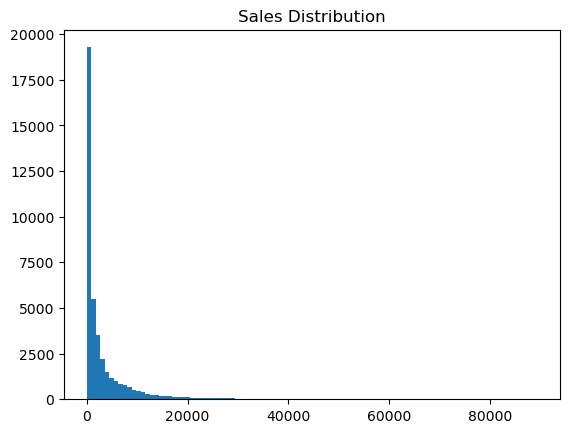

In [40]:
#Sales Distribution
plt.hist(df_master["Sales"], bins=100)
plt.title("Sales Distribution")
plt.show()

## Machine Learning Data Prep

### ML Data Prep

In [41]:
cols_to_drop = [
    "Date",                 # redundant + not usable directly
    "Model",                # prevent developing a bias,
    "mpg",                  # = 0 for EVs
    "mpge",                 # = 0 for Non-EVs 
    # "Projected",            # incomplete column
    "actual_launch_month",
    "actual_launch_year",
    "actual_end_month",    # FUTURE info
    "actual_end_year"              # FUTURE info
]

df_A = df_master.drop(columns=cols_to_drop)

In [42]:
#Data Check
missing_summary = df_A.isnull().sum().sort_values(ascending=False)
print(missing_summary)

Maker/Brand             0
PowerTrain              0
Sales                   0
Year                    0
Month                   0
Accel_sec               0
TopSpeed_mph            0
energy_kwh_per_100mi    0
Range_mi                0
Power                   0
Torque                  0
Weight_lb               0
Payload_lb              0
Cargo_ft3               0
BodyStyle               0
Seats                   0
Price_usd               0
Luxury                  0
months_since_launch     0
PowerTrain_simple       0
dtype: int64


### Adding Features

In [43]:
#log price
df_A["log_price"] = np.log1p(df_A["Price_usd"])

In [44]:
#confirming column data types
df_A["PowerTrain"] = df_A["PowerTrain"].astype("category")
df_A["PowerTrain_simple"] = df_A["PowerTrain_simple"].astype("category")
df_A["Maker/Brand"] = df_A["Maker/Brand"].astype("category")

In [45]:
# Ratios
df_A["power_to_weight"] = df_A["Power"] / df_A["Weight_lb"]
df_A["price_per_hp"] = df_A["Price_usd"] / df_A["Power"]

In [46]:
#Seasonality
df_A["month_sin"] = np.sin(2 * np.pi * df_A["Month"] / 12)
df_A["month_cos"] = np.cos(2 * np.pi * df_A["Month"] / 12)
#drop month
df_A = df_A.drop(columns=["Month"])

In [47]:
#captures cheap vs expensive within luxury category
df_A["avg_segment_price"] = df_A.groupby("Luxury")["Price_usd"].transform("mean")
df_A["price_vs_segment"] = df_A["Price_usd"] / df_A["avg_segment_price"]
#drop redundant column
df_A = df_A.drop(columns=["avg_segment_price"])

In [48]:
#copy for later use
df_B = df_A.copy()
df_B.columns

Index(['Maker/Brand', 'PowerTrain', 'Sales', 'Year', 'Accel_sec',
       'TopSpeed_mph', 'energy_kwh_per_100mi', 'Range_mi', 'Power', 'Torque',
       'Weight_lb', 'Payload_lb', 'Cargo_ft3', 'BodyStyle', 'Seats',
       'Price_usd', 'Luxury', 'months_since_launch', 'PowerTrain_simple',
       'log_price', 'power_to_weight', 'price_per_hp', 'month_sin',
       'month_cos', 'price_vs_segment'],
      dtype='object')

### Defining Feature Columns

In [49]:
#Define Feature Sets
num_cols = [
    'Accel_sec', 'TopSpeed_mph', 'energy_kwh_per_100mi',
    'Range_mi', 'Power', 'Torque', 'Weight_lb',
    'Payload_lb', 'Cargo_ft3', 'Seats', 'Price_usd',
    'months_since_launch', 'log_price',
    'power_to_weight', 'price_per_hp',
    'month_sin', 'month_cos', 'price_vs_segment'
]


cat_cols = [
    'Maker/Brand',
    # 'Model', #remove later as this creates bias
    'BodyStyle',
    'PowerTrain',
    'PowerTrain_simple',
    'Luxury'
]

## Light GBM Regression 

In [50]:
#Predicting Automotive Success for First 12 Months of Release

In [51]:
# Launch-Year Model: First 12 Months Only
# Target: Sales
# Purpose: Predict sales potential for a new vehicle launch

import numpy as np
import pandas as pd
import lightgbm as lgb

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Create launch-year dataset

df_launch = df_B.copy()

df_launch = df_launch[
    (df_launch["months_since_launch"] >= 0) &
    (df_launch["months_since_launch"] <= 12)
].copy()

print("Launch-year rows:", df_launch.shape)
print(df_launch["months_since_launch"].describe())


Launch-year rows: (2589, 25)
count    2589.000000
mean        5.998455
std         3.727275
min         0.000000
25%         3.000000
50%         6.000000
75%         9.000000
max        12.000000
Name: months_since_launch, dtype: float64


In [52]:

# 2. Define target and features

target_col = "Sales"

drop_cols = ["Sales"]

X = df_launch.drop(columns=drop_cols)
y = df_launch[target_col]

cat_cols = [
    "Maker/Brand",
    'BodyStyle',
    "PowerTrain",
    "PowerTrain_simple",
    "Luxury"
]

for col in cat_cols:
    X[col] = X[col].astype("category")


In [53]:
# 3. Random train/test split
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

print("Train rows:", X_train.shape)
print("Test rows:", X_test.shape)


# 4. Train LightGBM launch model

launch_model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=20,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42
)

launch_model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    eval_metric="rmse",
    categorical_feature=cat_cols,
    callbacks=[lgb.early_stopping(50)]
)


#5. Evaluate model

#Since target_col = "Sales", predictions are already in raw sales units
y_pred_sales = launch_model.predict(X_test)

#sales cannot be negative
y_pred_sales = np.clip(y_pred_sales, 0, None)

mae_sales = mean_absolute_error(y_test, y_pred_sales)
rmse_sales = np.sqrt(mean_squared_error(y_test, y_pred_sales))
r2_sales = r2_score(y_test, y_pred_sales)

print("MAE sales:", mae_sales)
print("RMSE sales:", rmse_sales)
print("R2 sales:", r2_sales)


# 6. Feature importance

feat_imp_launch = pd.DataFrame({
    "feature": X.columns,
    "importance": launch_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feat_imp_launch.head(15))

Train rows: (1812, 24)
Test rows: (777, 24)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000369 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1706
[LightGBM] [Info] Number of data points in the train set: 1812, number of used features: 24
[LightGBM] [Info] Start training from score 1030.120861
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

## Results Discussion

### Results Dataframe

In [54]:
# Launch-Year Model Visual Diagnostics

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. results dataframe
results_launch = X_test.copy()

# y_test is already raw Sales now
results_launch["Sales_actual"] = y_test.values
results_launch["Sales_pred"] = y_pred_sales

results_launch["Residual_sales"] = (
    results_launch["Sales_actual"] - results_launch["Sales_pred"]
)

results_launch.head()

,Maker/Brand,PowerTrain,Year,Accel_sec,TopSpeed_mph,energy_kwh_per_100mi,Range_mi,Power,Torque,Weight_lb,...,PowerTrain_simple,log_price,power_to_weight,price_per_hp,month_sin,month_cos,price_vs_segment,Sales_actual,Sales_pred,Residual_sales
22499,FORD,PHV,2021,7.5,120.0,52.3,540.0,221.0,155.0,3800.0,...,Hybrid,10.434145,0.058158,153.846154,5.000000e-01,8.660254e-01,0.982402,6,139.556073,-133.556073
22313,TESLA,EV,2020,4.8,135.0,27.9,326.0,384.0,376.0,4400.0,...,EV,10.778977,0.087273,125.000000,-2.449294e-16,1.000000e+00,0.763229,16000,10573.932167,5426.067833
49318,JEEP,EV,2025,3.5,124.0,35.5,300.0,600.0,617.0,5600.0,...,EV,11.191356,0.107143,120.833333,-1.000000e+00,-1.836970e-16,2.085036,1657,1369.592821,287.407179
7013,KIA,ICE,2017,5.6,167.0,95.1,410.0,365.0,376.0,3900.0,...,ICE,10.571343,0.093590,106.849315,-1.000000e+00,-1.836970e-16,1.126873,0,777.596528,-777.596528
12369,VOLVO CARS,ICE,2018,6.4,130.0,77.5,470.0,248.0,258.0,3900.0,...,ICE,10.463132,0.063590,141.129032,-5.000000e-01,8.660254e-01,0.556521,1022,1137.693102,-115.693102


### Feature Importance

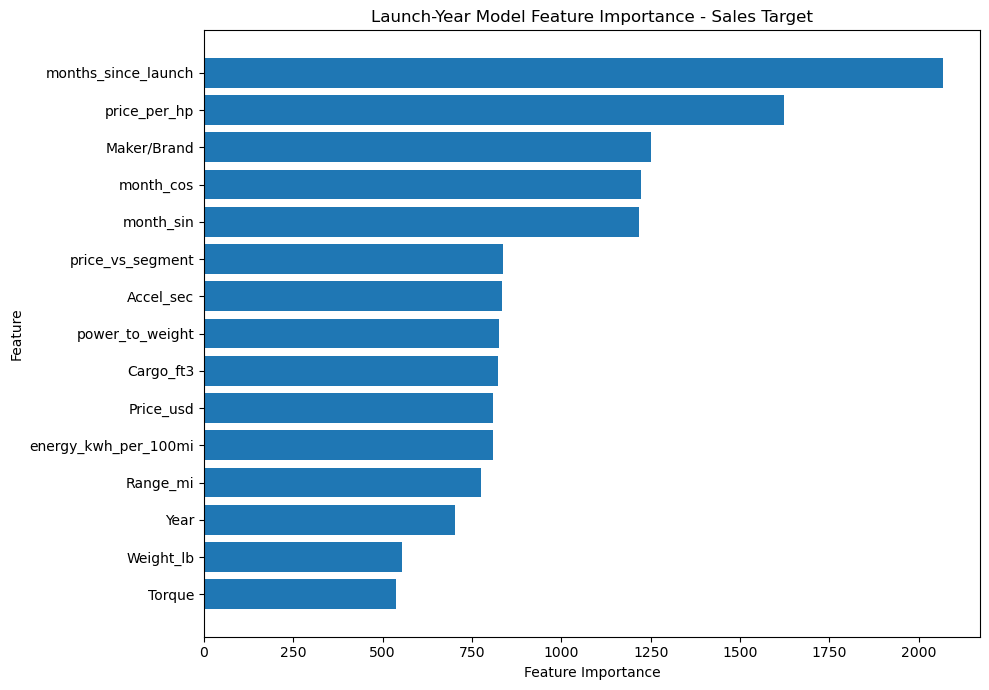

                 feature  importance
16   months_since_launch        2068
20          price_per_hp        1624
0            Maker/Brand        1251
22             month_cos        1223
21             month_sin        1217
23      price_vs_segment         836
3              Accel_sec         834
19       power_to_weight         826
11             Cargo_ft3         822
14             Price_usd         810
5   energy_kwh_per_100mi         808
6               Range_mi         775
2                   Year         702
9              Weight_lb         553
8                 Torque         538
7                  Power         452
10            Payload_lb         280
4           TopSpeed_mph         276
17     PowerTrain_simple         156
18             log_price         149
15                Luxury         128
13                 Seats         115
1             PowerTrain          62
12             BodyStyle          41


In [55]:

# Launch-Year Model Visual Diagnostics
# Based on results_launch dataframe

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

results_launch["months_since_launch"] = pd.to_numeric(
    results_launch["months_since_launch"],
    errors="coerce"
)

# 1. Feature Importance

top_n = 15

feat_imp_plot = (
    feat_imp_launch
    .head(top_n)
    .sort_values("importance", ascending=True)
)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp_plot["feature"], feat_imp_plot["importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Launch-Year Model Feature Importance - Sales Target")
plt.tight_layout()
plt.show()

print(feat_imp_launch)

In [56]:
df_launch.columns

Index(['Maker/Brand', 'PowerTrain', 'Sales', 'Year', 'Accel_sec',
       'TopSpeed_mph', 'energy_kwh_per_100mi', 'Range_mi', 'Power', 'Torque',
       'Weight_lb', 'Payload_lb', 'Cargo_ft3', 'BodyStyle', 'Seats',
       'Price_usd', 'Luxury', 'months_since_launch', 'PowerTrain_simple',
       'log_price', 'power_to_weight', 'price_per_hp', 'month_sin',
       'month_cos', 'price_vs_segment'],
      dtype='object')

### Model Performance

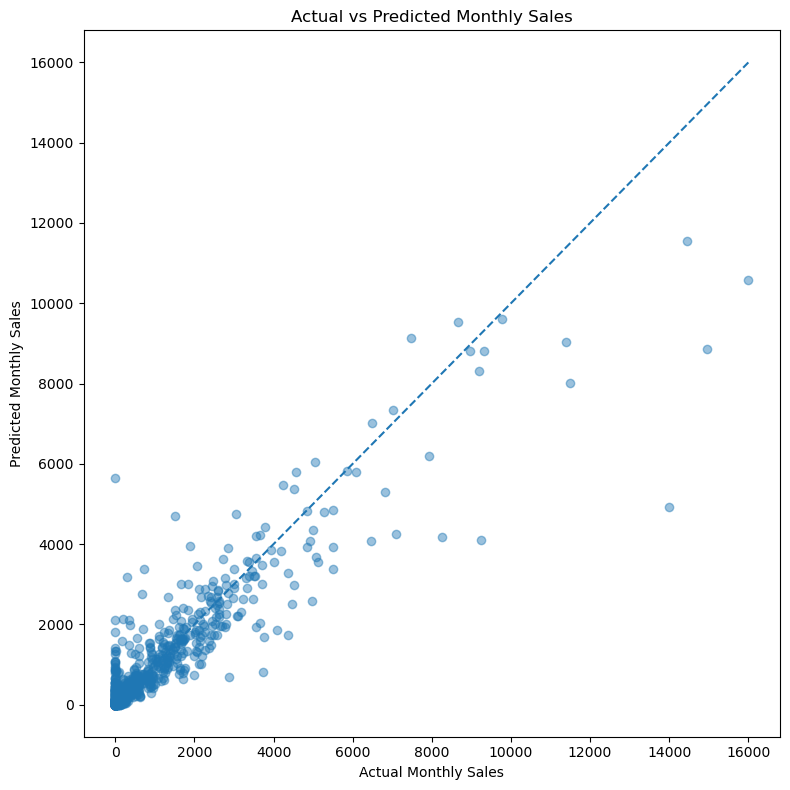

In [57]:
#Actual vs Predicted Sales

plt.figure(figsize=(8, 8))

plt.scatter(
    results_launch["Sales_actual"],
    results_launch["Sales_pred"],
    alpha=0.45
)

max_val = max(
    results_launch["Sales_actual"].max(),
    results_launch["Sales_pred"].max()
)

plt.plot([0, max_val], [0, max_val], linestyle="--")

plt.xlabel("Actual Monthly Sales")
plt.ylabel("Predicted Monthly Sales")
plt.title("Actual vs Predicted Monthly Sales")
plt.tight_layout()
plt.show()




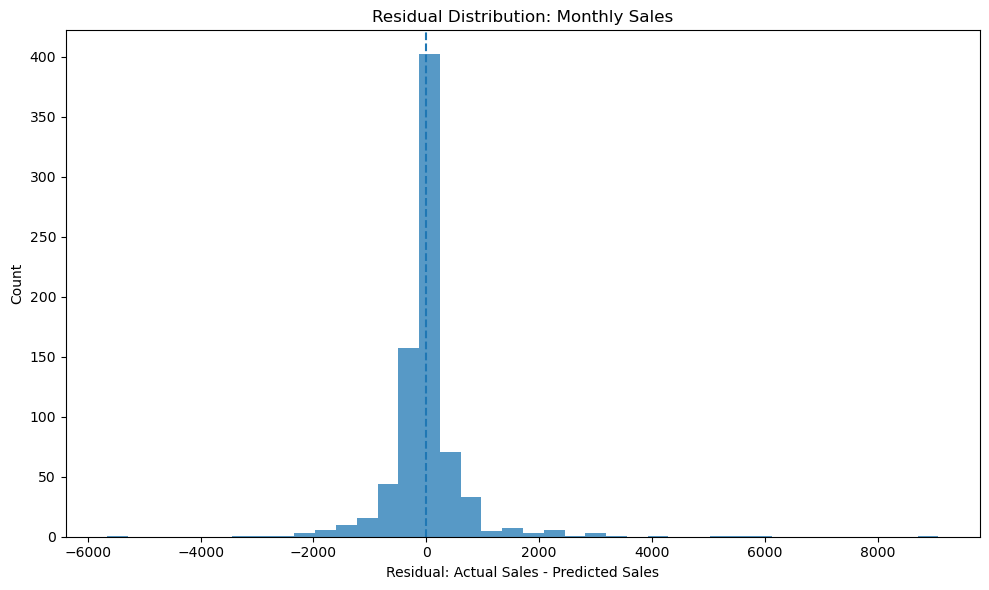

In [58]:

#Residual Distribution: Sales Scale

plt.figure(figsize=(10, 6))

plt.hist(
    results_launch["Residual_sales"],
    bins=40,
    alpha=0.75
)

plt.axvline(0, linestyle="--")

plt.xlabel("Residual: Actual Sales - Predicted Sales")
plt.ylabel("Count")
plt.title("Residual Distribution: Monthly Sales")
plt.tight_layout()
plt.show()



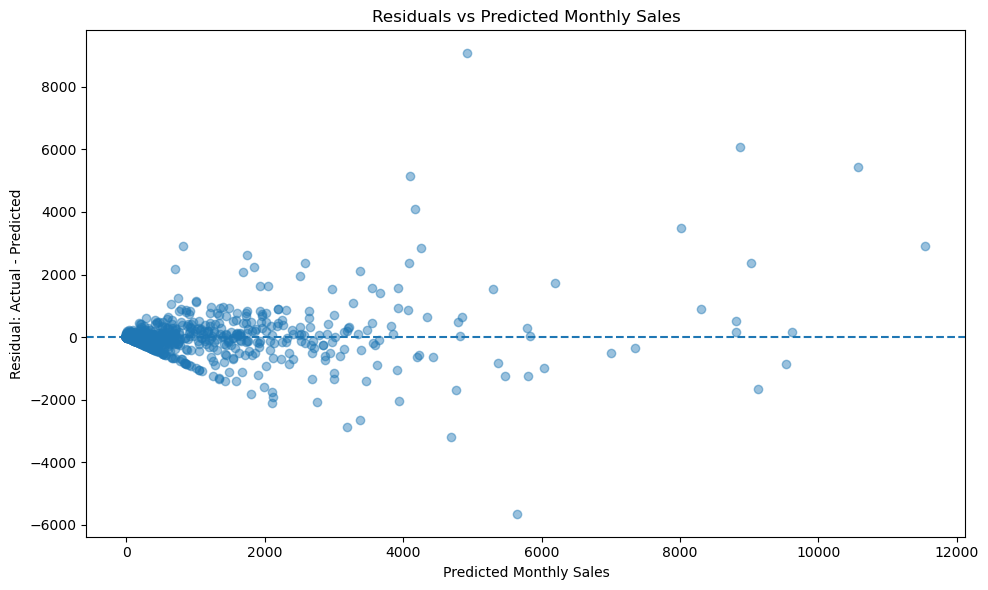

In [59]:
#Residuals vs Predicted Sales

plt.figure(figsize=(10, 6))

plt.scatter(
    results_launch["Sales_pred"],
    results_launch["Residual_sales"],
    alpha=0.45
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Monthly Sales")
plt.ylabel("Residual: Actual - Predicted")
plt.title("Residuals vs Predicted Monthly Sales")
plt.tight_layout()
plt.show()

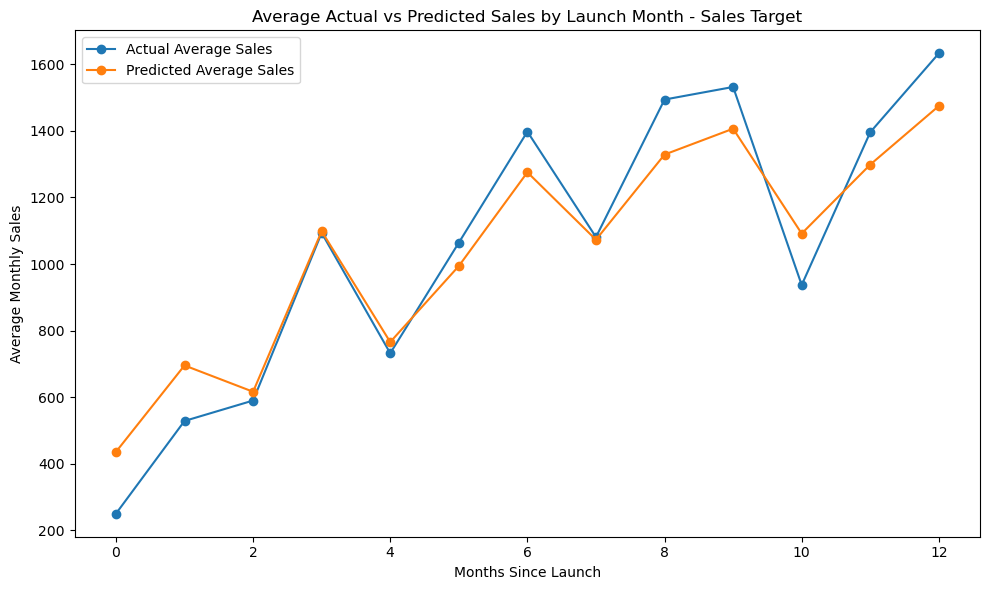

In [60]:

#Average Actual vs Predicted Sales by Months Since Launch

launch_curve = (
    results_launch
    .groupby("months_since_launch")[["Sales_actual", "Sales_pred"]]
    .mean()
    .reset_index()
    .sort_values("months_since_launch")
)

plt.figure(figsize=(10, 6))

plt.plot(
    launch_curve["months_since_launch"],
    launch_curve["Sales_actual"],
    marker="o",
    label="Actual Average Sales"
)

plt.plot(
    launch_curve["months_since_launch"],
    launch_curve["Sales_pred"],
    marker="o",
    label="Predicted Average Sales"
)

plt.xlabel("Months Since Launch")
plt.ylabel("Average Monthly Sales")
plt.title("Average Actual vs Predicted Sales by Launch Month - Sales Target")
plt.legend()
plt.tight_layout()
plt.show()




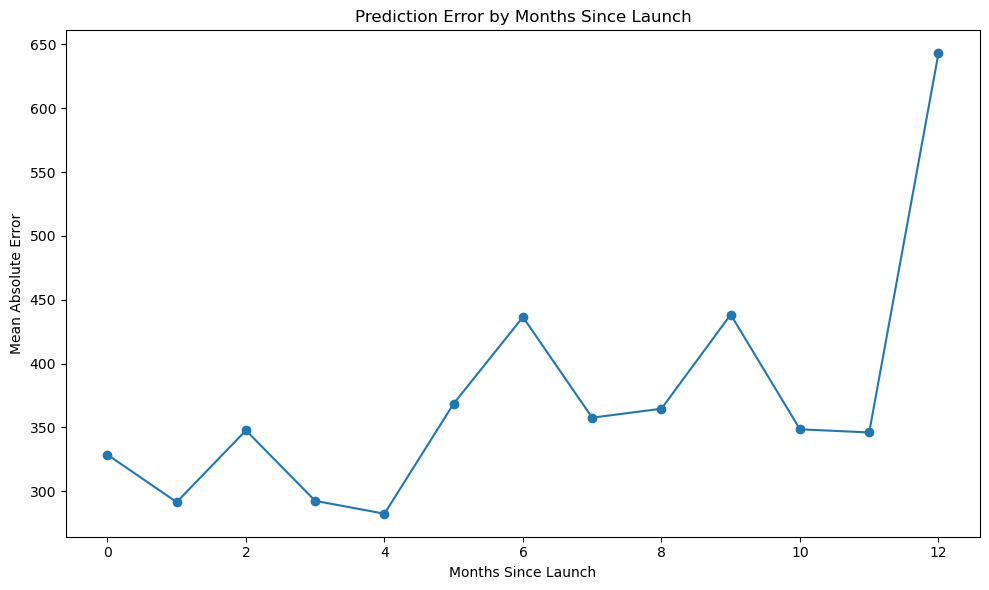

In [61]:
#MAE by Months Since Launch

launch_error = (
    results_launch
    .assign(abs_error=lambda d: np.abs(d["Sales_actual"] - d["Sales_pred"]))
    .groupby("months_since_launch")["abs_error"]
    .mean()
    .reset_index()
    .sort_values("months_since_launch")
)

plt.figure(figsize=(10, 6))

plt.plot(
    launch_error["months_since_launch"],
    launch_error["abs_error"],
    marker="o"
)

plt.xlabel("Months Since Launch")
plt.ylabel("Mean Absolute Error")
plt.title("Prediction Error by Months Since Launch")
plt.tight_layout()
plt.show()

/var/folders/7x/f6nfh61n4s139_5hy27xjlhc0000gn/T/ipykernel_30618/1120296380.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_launch


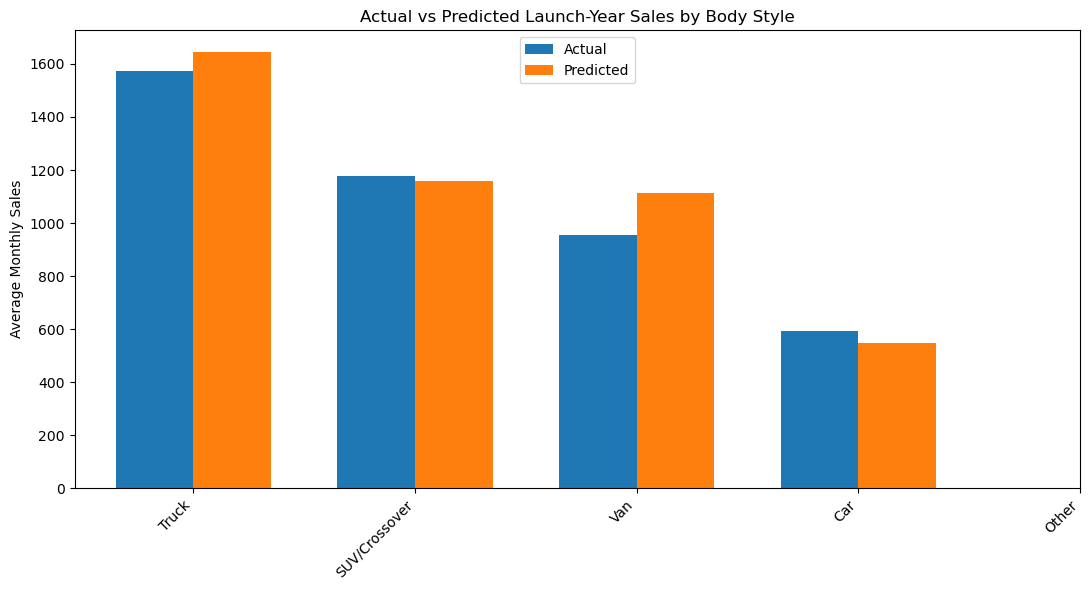

/var/folders/7x/f6nfh61n4s139_5hy27xjlhc0000gn/T/ipykernel_30618/1120296380.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_launch


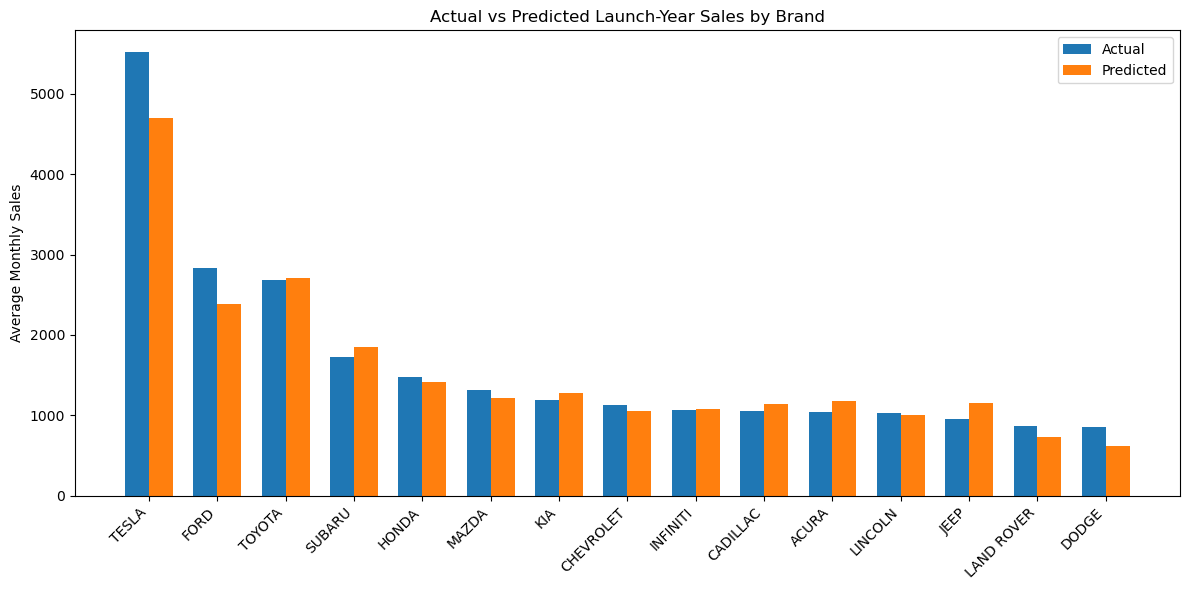

In [62]:
#Actual vs Predicted by BodyStyle

body_perf = (
    results_launch
    .groupby("BodyStyle")[["Sales_actual", "Sales_pred"]]
    .mean()
    .reset_index()
)

body_perf["abs_error"] = np.abs(
    body_perf["Sales_actual"] - body_perf["Sales_pred"]
)

body_perf = body_perf.sort_values("Sales_actual", ascending=False)

x = np.arange(len(body_perf))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    body_perf["Sales_actual"],
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    body_perf["Sales_pred"],
    width,
    label="Predicted"
)

plt.xticks(
    x,
    body_perf["BodyStyle"].astype(str),
    rotation=45,
    ha="right"
)

plt.ylabel("Average Monthly Sales")
plt.title("Actual vs Predicted Launch-Year Sales by Body Style")
plt.legend()
plt.tight_layout()
plt.show()


#Actual vs Predicted by Brand

brand_perf = (
    results_launch
    .groupby("Maker/Brand")[["Sales_actual", "Sales_pred"]]
    .mean()
    .reset_index()
)

brand_perf["abs_error"] = np.abs(
    brand_perf["Sales_actual"] - brand_perf["Sales_pred"]
)

brand_perf_top = brand_perf.sort_values(
    "Sales_actual",
    ascending=False
).head(15)

x = np.arange(len(brand_perf_top))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    brand_perf_top["Sales_actual"],
    width,
    label="Actual"
)

plt.bar(
    x + width / 2,
    brand_perf_top["Sales_pred"],
    width,
    label="Predicted"
)

plt.xticks(
    x,
    brand_perf_top["Maker/Brand"].astype(str),
    rotation=45,
    ha="right"
)

plt.ylabel("Average Monthly Sales")
plt.title("Actual vs Predicted Launch-Year Sales by Brand")
plt.legend()
plt.tight_layout()
plt.show()



## Hypothetical Sales Prediction 

### Define Hypothetical Vehicle

In [63]:
df_B["BodyStyle"].drop_duplicates()

0               Car
2     SUV/Crossover
57            Truck
59              Van
Name: BodyStyle, dtype: category
Categories (5, object): ['Car', 'Other', 'SUV/Crossover', 'Truck', 'Van']

In [64]:
#Scout Traveler Specs

base_vehicle = {
    "Maker/Brand": "VW",
    "PowerTrain": "EREV",
    "PowerTrain_simple": "Hybrid",  # consider PHEV/EREV later
    "BodyStyle": "SUV/Crossover",


    "Year": 2027,
    "Accel_sec": 3.5,
    "TopSpeed_mph": 155,
    "energy_kwh_per_100mi": 45,
    "Range_mi": 500,

    "Power": 500,
    "Torque": 900,
    "Weight_lb": 6200,
    "Payload_lb": 1400,
    "Cargo_ft3": 85,

    "Seats": 5,
    "Price_usd": 60000,
    "Luxury": 2,

    "log_price": np.log1p(60000),
    "power_to_weight": 500 / 6200,
    "price_per_hp": 60000 / 500,

    "price_vs_segment": 1.10
}

### Sales Prediction

In [65]:

def simulate_first_year_sales(model, base_vehicle, feature_cols, cat_cols):
    rows = []

    for month in range(1, 13):
        row = base_vehicle.copy()

        # Month-specific launch timing
        row["months_since_launch"] = month - 1

        # Seasonality features
        row["month_sin"] = np.sin(2 * np.pi * month / 12)
        row["month_cos"] = np.cos(2 * np.pi * month / 12)

        rows.append(row)

    pred_df = pd.DataFrame(rows)

    # Keep only model features and correct order
    pred_df = pred_df[feature_cols].copy()

    # Match categorical dtype from training data
    for col in cat_cols:
        pred_df[col] = pred_df[col].astype("category")

        # if training X[col] was categorical, align categories
        if hasattr(X[col], "cat"):
            pred_df[col] = pred_df[col].cat.set_categories(X[col].cat.categories)

    # Predict actual sales directly
    pred_df["Predicted_Sales"] = model.predict(pred_df[feature_cols])

    # Sales cannot be negative
    pred_df["Predicted_Sales"] = np.clip(pred_df["Predicted_Sales"], 0, None)

    # Add readable month column
    pred_df["Launch_Month"] = np.arange(1, 13)

    return pred_df


scout_pred = simulate_first_year_sales(
    model=launch_model,
    base_vehicle=base_vehicle,
    feature_cols=X.columns,
    cat_cols=cat_cols
)

scout_pred[["Launch_Month", "months_since_launch", "Predicted_Sales"]]

,Launch_Month,months_since_launch,Predicted_Sales
0,1,0,0.000000
1,2,1,0.000000
2,3,2,69.885190
3,4,3,261.071172
4,5,4,465.299259
5,6,5,520.689959
6,7,6,599.285444
7,8,7,934.421245
8,9,8,1093.385455
9,10,9,870.491331


### Benchmark Vehicles

In [66]:
#Possible Benchmarks 

df_master[
    (df_master["BodyStyle"] == "SUV/Crossover") &
    (df_master["PowerTrain"] != "ICE") &
    (df_master["months_since_launch"] < 12)
][["Maker/Brand", "Model", "PowerTrain","PowerTrain_simple"]].drop_duplicates()

,Maker/Brand,Model,PowerTrain,PowerTrain_simple
41,BMW,X5,PHV,Hybrid
164,KIA,NIRO,HV,Hybrid
225,MERCEDES-BENZ,GLE-CLASS (M-CLASS/ML-CLASS),PHV,Hybrid
276,TESLA,MODEL X,EV,EV
296,TOYOTA,RAV4,HV,Hybrid
...,...,...,...,...
45150,JEEP,WAGONEER S,EV,EV
45226,LUCID MOTORS,GRAVITY,EV,EV
45341,TOYOTA,4RUNNER,MHV,Hybrid
47199,HYUNDAI,IONIQ 9,EV,EV


In [67]:
#Add benchmark labels to df_master


df_master_compare = df_master.copy()

# Normalize text columns
df_master_compare["Maker/Brand"] = (
    df_master_compare["Maker/Brand"].astype(str).str.upper().str.strip()
)

df_master_compare["Model"] = (
    df_master_compare["Model"].astype(str).str.upper().str.strip()
)

df_master_compare["PowerTrain"] = (
    df_master_compare["PowerTrain"].astype(str).str.upper().str.strip()
)

df_master_compare["BodyStyle"] = (
    df_master_compare["BodyStyle"].astype(str).str.upper().str.strip()
)

In [68]:
benchmark_models = [
    # ("FORD", "EXPLORER", "HV"),
    ("CHEVROLET", "BLAZER EV", "EV"),
    # ("ACURA", "MDX", "HV"),
    # ("BMW", "X5", "PHV"),
    ("AUDI", "Q4 E-TRON", "EV"),
    # ("AUDI", "Q5", "PHV"),
    # ("JEEP", "WRANGLER", "PHV"),
    # ("JEEP", "WAGONEER", "ICE"),    
    ("LEXUS", "NX", "PHV"),
    ("GENESIS", "GV60", "EV"),
    ("GENESIS", "GV70", "EV"),
    ("CADILLAC", "LYRIQ", "EV"),
    # ("LEXUS", "RX", "PHV"),
    ("FORD", "MACH-E"),
    ("FORD", "MUSTANG MACH-E"),
    ("RIVIAN", "R1S"),
    ("RIVIAN", "R1T"),
    ("LEXUS", "RZ", "EV"),
    ("LEXUS", "TX", "EV"),
    ("VOLVO CARS", "EC40", "EV"),
    # ("ACURA", "ZDX", "EV"),
    # ("CADILLAC", "OPTIQ", "EV"),
    # ("HYUNDAI", "IONIQ 9", "EV")
]


In [69]:


benchmark_set = set(benchmark_models)

def assign_benchmark_group(row):
    combo = (row["Maker/Brand"], row["Model"], row["PowerTrain"])

    if combo in benchmark_set:
        return "Similar SUV Benchmark"

    elif row["BodyStyle"] == "SUV/CROSSOVER" and row["PowerTrain"] in ["EV", "PHV", "HV", "MHV"]:
        return "General Electrified SUV/Crossover Benchmark"

    else:
        return "Other"

df_master_compare["benchmark_group"] = df_master_compare.apply(
    assign_benchmark_group,
    axis=1
)

df_master_compare["benchmark_group"].value_counts()

benchmark_group
Other                                          34997
General Electrified SUV/Crossover Benchmark     5426
Similar SUV Benchmark                            253
Name: count, dtype: int64

In [70]:
#Filter benchmark vehicles to first 12 launch months

benchmark_first_year = df_master_compare[
    (df_master_compare["months_since_launch"] >= 0) &
    (df_master_compare["months_since_launch"] <= 11) &
    (df_master_compare["benchmark_group"] != "Other")
].copy()

benchmark_first_year[
    [
        "Maker/Brand", 
        "Model", 
        "PowerTrain", 
        "BodyStyle",
        "Date",
        "months_since_launch", 
        "Sales", 
        "benchmark_group"
    ]
].head()

,Maker/Brand,Model,PowerTrain,BodyStyle,Date,months_since_launch,Sales,benchmark_group
41,BMW,X5,PHV,SUV/CROSSOVER,2016-01,3.0,181,General Electrified SUV/Crossover Benchmark
164,KIA,NIRO,HV,SUV/CROSSOVER,2016-01,0.0,0,General Electrified SUV/Crossover Benchmark
225,MERCEDES-BENZ,GLE-CLASS (M-CLASS/ML-CLASS),PHV,SUV/CROSSOVER,2016-01,5.0,0,General Electrified SUV/Crossover Benchmark
276,TESLA,MODEL X,EV,SUV/CROSSOVER,2016-01,4.0,400,General Electrified SUV/Crossover Benchmark
296,TOYOTA,RAV4,HV,SUV/CROSSOVER,2016-01,2.0,1973,General Electrified SUV/Crossover Benchmark


### Compare Hypothetical Vehicle to Benchmark Vehicles

In [71]:
#Format Scout prediction like benchmark data

scout_compare = scout_pred.copy()

scout_compare["Maker/Brand"] = "SCOUT"
scout_compare["Model"] = "TRAVELER"
scout_compare["PowerTrain"] = "EREV"
scout_compare["BodyStyle"] = "SUV"
scout_compare["Sales"] = scout_compare["Predicted_Sales"]
scout_compare["benchmark_group"] = "Scout Prediction"

#launch date labels
scout_compare["Date"] = pd.date_range(
    start="2026-01-01",
    periods=12,
    freq="MS"
).strftime("%Y-%m")

scout_compare = scout_compare[
    [
        "Maker/Brand",
        "Model",
        "PowerTrain",
        "BodyStyle",
        "Date",
        "months_since_launch",
        "Sales",
        "benchmark_group"
    ]
]

scout_compare.head()

,Maker/Brand,Model,PowerTrain,BodyStyle,Date,months_since_launch,Sales,benchmark_group
0,SCOUT,TRAVELER,EREV,SUV,2026-01,0,0.000000,Scout Prediction
1,SCOUT,TRAVELER,EREV,SUV,2026-02,1,0.000000,Scout Prediction
2,SCOUT,TRAVELER,EREV,SUV,2026-03,2,69.885190,Scout Prediction
3,SCOUT,TRAVELER,EREV,SUV,2026-04,3,261.071172,Scout Prediction
4,SCOUT,TRAVELER,EREV,SUV,2026-05,4,465.299259,Scout Prediction


In [72]:
#Combine Scout prediction with benchmark vehicles

comparison_df = pd.concat(
    [
        benchmark_first_year[
            [
                "Maker/Brand",
                "Model",
                "PowerTrain",
                "BodyStyle",
                "Date",
                "months_since_launch",
                "Sales",
                "benchmark_group"
            ]
        ],
        scout_compare
    ],
    ignore_index=True
)

comparison_df["vehicle_label"] = (
    comparison_df["Maker/Brand"] + " " +
    comparison_df["Model"] + " " +
    comparison_df["PowerTrain"]
)

comparison_df.head()

,Maker/Brand,Model,PowerTrain,BodyStyle,Date,months_since_launch,Sales,benchmark_group,vehicle_label
0,BMW,X5,PHV,SUV/CROSSOVER,2016-01,3.0,181.0,General Electrified SUV/Crossover Benchmark,BMW X5 PHV
1,KIA,NIRO,HV,SUV/CROSSOVER,2016-01,0.0,0.0,General Electrified SUV/Crossover Benchmark,KIA NIRO HV
2,MERCEDES-BENZ,GLE-CLASS (M-CLASS/ML-CLASS),PHV,SUV/CROSSOVER,2016-01,5.0,0.0,General Electrified SUV/Crossover Benchmark,MERCEDES-BENZ GLE-CLASS (M-CLASS/ML-CLASS) PHV
3,TESLA,MODEL X,EV,SUV/CROSSOVER,2016-01,4.0,400.0,General Electrified SUV/Crossover Benchmark,TESLA MODEL X EV
4,TOYOTA,RAV4,HV,SUV/CROSSOVER,2016-01,2.0,1973.0,General Electrified SUV/Crossover Benchmark,TOYOTA RAV4 HV


In [73]:
#First-year total sales comparison

first_year_summary = (
    comparison_df
    .groupby(["vehicle_label", "benchmark_group"], as_index=False)
    .agg(
        first_year_sales=("Sales", "sum"),
        avg_monthly_sales=("Sales", "mean"),
        max_monthly_sales=("Sales", "max"),
        months_observed=("months_since_launch", "nunique")
    )
    .sort_values("first_year_sales", ascending=False)
)

first_year_summary

,vehicle_label,benchmark_group,first_year_sales,avg_monthly_sales,max_monthly_sales,months_observed
78,TESLA MODEL Y EV,General Electrified SUV/Crossover Benchmark,93950.0,7829.166667,16000.0,12
87,TOYOTA VENZA HV,General Electrified SUV/Crossover Benchmark,59220.0,4935.000000,9241.0,12
17,CHEVROLET EQUINOX EV,General Electrified SUV/Crossover Benchmark,45289.0,3774.083333,7097.0,12
83,TOYOTA LAND CRUISER 250 MHV,General Electrified SUV/Crossover Benchmark,44529.0,3710.750000,6182.0,12
25,HONDA PROLOGUE EV,General Electrified SUV/Crossover Benchmark,39694.0,3307.833333,7885.0,12
...,...,...,...,...,...,...
55,MAZDA CX-50 HV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12
81,TOYOTA COROLLA CROSS HV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12
74,SUBARU FORESTER HV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12
95,VOLVO CARS XC60 MHV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12


In [74]:

first_year_summary = (
    comparison_df
    .groupby(["vehicle_label", "benchmark_group"], as_index=False)
    .agg(
        first_year_sales=("Sales", "sum"),
        avg_monthly_sales=("Sales", "mean"),
        max_monthly_sales=("Sales", "max"),
        months_observed=("months_since_launch", "nunique")
    )
    .sort_values("first_year_sales", ascending=False)
)

first_year_summary

,vehicle_label,benchmark_group,first_year_sales,avg_monthly_sales,max_monthly_sales,months_observed
78,TESLA MODEL Y EV,General Electrified SUV/Crossover Benchmark,93950.0,7829.166667,16000.0,12
87,TOYOTA VENZA HV,General Electrified SUV/Crossover Benchmark,59220.0,4935.000000,9241.0,12
17,CHEVROLET EQUINOX EV,General Electrified SUV/Crossover Benchmark,45289.0,3774.083333,7097.0,12
83,TOYOTA LAND CRUISER 250 MHV,General Electrified SUV/Crossover Benchmark,44529.0,3710.750000,6182.0,12
25,HONDA PROLOGUE EV,General Electrified SUV/Crossover Benchmark,39694.0,3307.833333,7885.0,12
...,...,...,...,...,...,...
55,MAZDA CX-50 HV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12
81,TOYOTA COROLLA CROSS HV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12
74,SUBARU FORESTER HV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12
95,VOLVO CARS XC60 MHV,General Electrified SUV/Crossover Benchmark,0.0,0.000000,0.0,12


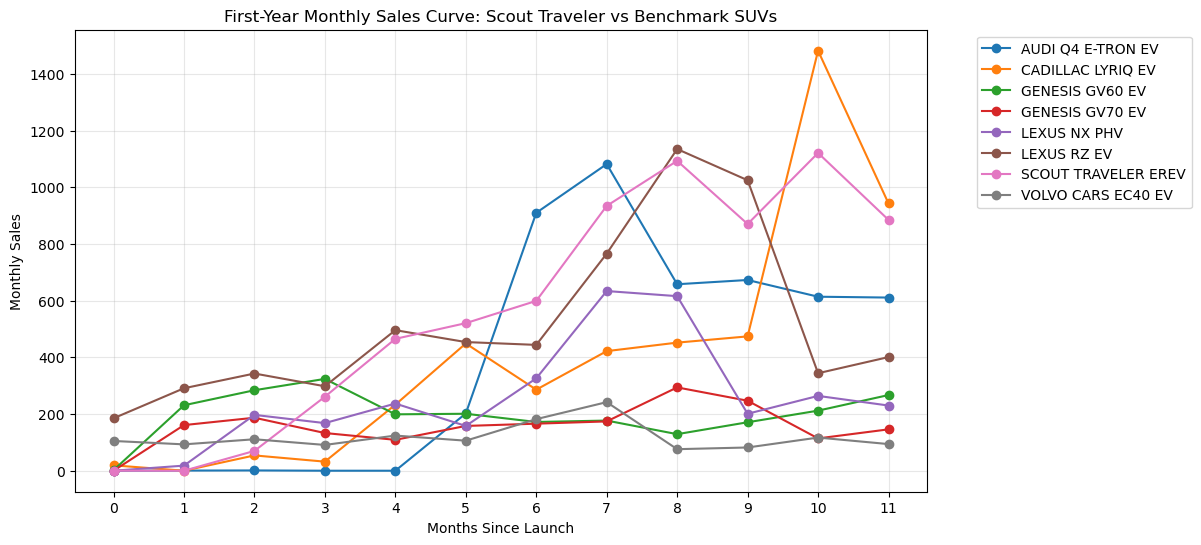

In [75]:
#Monthly launch curve comparison

monthly_curve = (
    comparison_df[
        comparison_df["benchmark_group"].isin([
            "Scout Prediction",
            # "Tesla Model Y Benchmark",
            "Similar SUV Benchmark"
        ])
    ]
    .groupby(["vehicle_label", "months_since_launch"], as_index=False)
    .agg(monthly_sales=("Sales", "sum"))
)

plt.figure(figsize=(11, 6))

for vehicle in monthly_curve["vehicle_label"].unique():
    temp = monthly_curve[monthly_curve["vehicle_label"] == vehicle]

    plt.plot(
        temp["months_since_launch"],
        temp["monthly_sales"],
        marker="o",
        label=vehicle
    )

plt.title("First-Year Monthly Sales Curve: Scout Traveler vs Benchmark SUVs")
plt.xlabel("Months Since Launch")
plt.ylabel("Monthly Sales")
plt.xticks(range(0, 12))
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### Compare Hypothetical Vehicle to Segment

In [76]:
benchmark_models = df_master[
    (df_master["BodyStyle"] == "SUV/Crossover") &
    (df_master["months_since_launch"] > 0) & 
    (df_master["months_since_launch"] < 12) & 
    (df_master["Price_usd"] >= 50000) & 
    (df_master["Price_usd"] <= 70000)    
][["Maker/Brand","Model","PowerTrain"]].drop_duplicates()

In [77]:
benchmark_models = (
    df_master[
        (df_master["BodyStyle"] == "SUV/Crossover") &
        (df_master["months_since_launch"] > 0) & 
        (df_master["months_since_launch"] < 12) & 
        (df_master["Price_usd"] >= 50000) & 
        (df_master["Price_usd"] <= 70000)
    ]
    .groupby(["Maker/Brand", "Model", "PowerTrain"], as_index=False)
    .agg(total_sales=("Sales", "sum"))
    .sort_values("total_sales", ascending=False)
    .head(25)
)

benchmark_models = list(
    benchmark_models[["Maker/Brand", "Model", "PowerTrain"]]
    .itertuples(index=False, name=None)
)

benchmark_models = set(benchmark_models)




comparison_df["benchmark_group"] = comparison_df.apply(
    assign_benchmark_group,
    axis=1
)


In [78]:
benchmark_set = set(benchmark_models)

df_master_compare["benchmark_group"] = df_master_compare.apply(
    assign_benchmark_group,
    axis=1
)

df_master_compare["benchmark_group"].value_counts()

#Filter benchmark vehicles to first 12 launch months

benchmark_first_year = df_master_compare[
    (df_master_compare["months_since_launch"] >= 0) &
    (df_master_compare["months_since_launch"] <= 11) &
    (df_master_compare["benchmark_group"] != "Other")
].copy()

In [79]:
#Combine Scout prediction with benchmark vehicles


comparison_df = pd.concat(
    [
        benchmark_first_year[
            [
                "Maker/Brand",
                "Model",
                "PowerTrain",
                "BodyStyle",
                "Date",
                "months_since_launch",
                "Sales",
                "benchmark_group"
            ]
        ],
        scout_compare
    ],
    ignore_index=True
)

comparison_df["vehicle_label"] = (
    comparison_df["Maker/Brand"] + " " +
    comparison_df["Model"] + " " +
    comparison_df["PowerTrain"]
)

comparison_df.head()

,Maker/Brand,Model,PowerTrain,BodyStyle,Date,months_since_launch,Sales,benchmark_group,vehicle_label
0,BMW,X5,PHV,SUV/CROSSOVER,2016-01,3.0,181.0,Similar SUV Benchmark,BMW X5 PHV
1,KIA,NIRO,HV,SUV/CROSSOVER,2016-01,0.0,0.0,General Electrified SUV/Crossover Benchmark,KIA NIRO HV
2,MERCEDES-BENZ,GLE-CLASS (M-CLASS/ML-CLASS),PHV,SUV/CROSSOVER,2016-01,5.0,0.0,General Electrified SUV/Crossover Benchmark,MERCEDES-BENZ GLE-CLASS (M-CLASS/ML-CLASS) PHV
3,TESLA,MODEL X,EV,SUV/CROSSOVER,2016-01,4.0,400.0,General Electrified SUV/Crossover Benchmark,TESLA MODEL X EV
4,TOYOTA,RAV4,HV,SUV/CROSSOVER,2016-01,2.0,1973.0,General Electrified SUV/Crossover Benchmark,TOYOTA RAV4 HV


In [80]:
# First-year sales ranking table

first_year_rank = (
    comparison_df[
        comparison_df["benchmark_group"].isin([
            "Scout Prediction",
            "Similar SUV Benchmark",
            ""
        ])
    ]
    .groupby(["vehicle_label", "benchmark_group"], as_index=False)
    .agg(
        first_year_sales=("Sales", "sum"),
        avg_monthly_sales=("Sales", "mean"),
        peak_monthly_sales=("Sales", "max"),
        months_observed=("months_since_launch", "nunique")
    )
    .sort_values("first_year_sales", ascending=False)
)

first_year_rank["rank"] = range(1, len(first_year_rank) + 1)

first_year_rank[
    [
        "rank",
        "vehicle_label",
        "benchmark_group",
        "first_year_sales",
        "avg_monthly_sales",
        "peak_monthly_sales",
        "months_observed"
    ]
]

,rank,vehicle_label,benchmark_group,first_year_sales,avg_monthly_sales,peak_monthly_sales,months_observed
22,1,TOYOTA LAND CRUISER 250 MHV,Similar SUV Benchmark,44529.00000,3710.750000,6182.000000,12
14,2,JEEP WAGONEER ICE,Similar SUV Benchmark,31478.00000,2623.166667,4450.000000,12
1,3,ACURA ZDX EV,Similar SUV Benchmark,29070.00000,2422.500000,4662.000000,12
15,4,JEEP WRANGLER PHV,Similar SUV Benchmark,24000.00000,2000.000000,6000.000000,12
16,5,KIA EV9 EV,Similar SUV Benchmark,19029.00000,1585.750000,2388.000000,12
3,6,AUDI Q6 EV,Similar SUV Benchmark,18930.00000,1720.909091,3595.000000,11
8,7,CADILLAC XT6 ICE,Similar SUV Benchmark,18717.00000,1559.750000,3178.000000,12
11,8,GENESIS GV80 ICE,Similar SUV Benchmark,18488.00000,1540.666667,2039.000000,12
17,9,LAND ROVER RANGE ROVER VELAR ICE,Similar SUV Benchmark,16219.00000,1351.583333,1987.000000,12
4,10,AUDI Q8 ICE,Similar SUV Benchmark,13470.00000,1122.500000,1469.000000,12


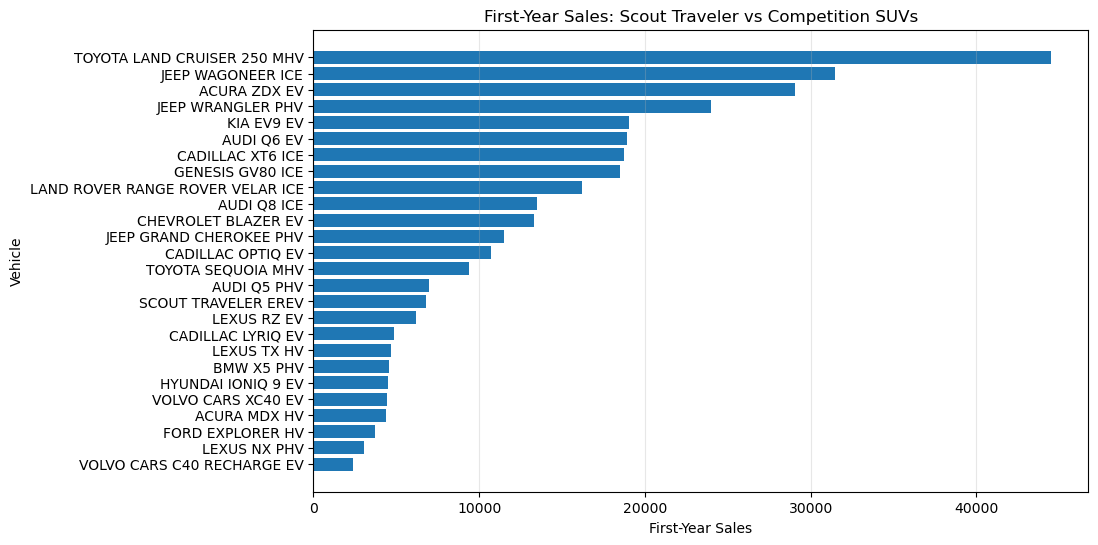

In [81]:
# First-year total sales bar chart

plot_df = first_year_rank.sort_values("first_year_sales", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["vehicle_label"],
    plot_df["first_year_sales"]
)

plt.title("First-Year Sales: Scout Traveler vs Competition SUVs")
plt.xlabel("First-Year Sales")
plt.ylabel("Vehicle")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [82]:
first_year_rank

,vehicle_label,benchmark_group,first_year_sales,avg_monthly_sales,peak_monthly_sales,months_observed,rank
22,TOYOTA LAND CRUISER 250 MHV,Similar SUV Benchmark,44529.00000,3710.750000,6182.000000,12,1
14,JEEP WAGONEER ICE,Similar SUV Benchmark,31478.00000,2623.166667,4450.000000,12,2
1,ACURA ZDX EV,Similar SUV Benchmark,29070.00000,2422.500000,4662.000000,12,3
15,JEEP WRANGLER PHV,Similar SUV Benchmark,24000.00000,2000.000000,6000.000000,12,4
16,KIA EV9 EV,Similar SUV Benchmark,19029.00000,1585.750000,2388.000000,12,5
3,AUDI Q6 EV,Similar SUV Benchmark,18930.00000,1720.909091,3595.000000,11,6
8,CADILLAC XT6 ICE,Similar SUV Benchmark,18717.00000,1559.750000,3178.000000,12,7
11,GENESIS GV80 ICE,Similar SUV Benchmark,18488.00000,1540.666667,2039.000000,12,8
17,LAND ROVER RANGE ROVER VELAR ICE,Similar SUV Benchmark,16219.00000,1351.583333,1987.000000,12,9
4,AUDI Q8 ICE,Similar SUV Benchmark,13470.00000,1122.500000,1469.000000,12,10
